# Clusters in Crisis: Unveiling Global Development Shifts Through the Pandemic

**Independent exploratory project**


**Sole author:** Christian Regie Jabagat


## Abstract

This study examines the structural clustering of economies across Pre-COVID (2019), Early COVID (2020), and Mid-COVID (2021) to assess how economic groupings evolved in response to the pandemic. Using hierarchical clustering and Jaccard similarity analysis, the results reveal that economic clusters were not static, with many economies experiencing fragmentation in 2020, followed by partial realignment in 2021, while others remained in newly formed clusters, indicating lasting structural shifts. The findings confirm that while some economies returned to their original classification, others continued along a new trajectory, suggesting that the pandemic fundamentally reshaped economic alignments rather than causing only temporary disruptions. The Jaccard similarity analysis highlights varying degrees of persistence and divergence, demonstrating that the crisis served as an economic stress test that sorted economies based on structural adaptability. Future research should incorporate probabilistic clustering techniques, such as Gaussian Mixture Models (GMM) and Hidden Markov Models (HMM), to capture economic transitions with greater precision and explore the impact of key policy interventions on structural realignment.

## Introduction

Economic structures are constantly evolving, shaped by global trade dynamics, policy shifts, technological advancements, and external shocks. While economies are often analyzed in isolation, understanding how they relate to one another in terms of structural similarities provides a broader perspective on economic transformation. The COVID-19 pandemic accelerated this transformation, disrupting trade flows, labor markets, and financial systems, forcing economies to adapt to new challenges at varying speeds. This disruption raises an important question: to what extent did economies retain their structural positioning, and to what extent did they transition into new alignments? Traditional economic analysis often focuses on individual country performance, yet a clustering-based approach can reveal underlying patterns of economic persistence, fragmentation, and realignment in ways that conventional metrics cannot fully capture.

This study applies hierarchical clustering to classify economies based on shared structural characteristics and Jaccard similarity analysis to track how these classifications evolved over three key periods—Pre-COVID (2019), Early COVID (2020), and Mid-COVID (2021). By assessing the degree of overlap between clusters over time, the research identifies whether economies remained stable, temporarily deviated before returning to their pre-pandemic classification, or underwent lasting structural shifts. Rather than relying on static classifications based on GDP or income level, this approach emphasizes how economies grouped and regrouped based on broader economic structures. Understanding these shifts is essential for recognizing which economies demonstrated structural resilience and which experienced prolonged realignment.

### Problem Statement

Economic structures are continuously reshaped by external shocks, policy interventions, and shifting trade and labor market dynamics. However, large-scale disruptions such as the COVID-19 pandemic do not just cause temporary contractions; they have the potential to fundamentally alter economic alignments by shifting how economies relate to one another structurally. Traditional economic classifications often rely on static income-based groupings, which fail to capture the fluidity of economic relationships and how they evolve over time. 

This study seeks to address a critical question: To what extent did economies retain their pre-pandemic structural clustering, and to what extent did they transition into new alignments during and after the crisis? By applying hierarchical clustering and Jaccard similarity analysis across Pre-COVID (2019), Early COVID (2020), and Mid-COVID (2021), this research tracks whether economies remained in their original clusters, experienced temporary realignments, or underwent lasting structural shifts. Understanding these transitions is essential for identifying patterns of economic resilience, fragmentation, and reconfiguration, offering a more nuanced, data-driven perspective on how economies shift in response to systemic global disruptions.

### Motivation

Understanding how economies evolve in response to global disruptions is essential for capturing the realignment of economic structures over time. While economic classifications have traditionally relied on static indicators such as GDP per capita, trade balances, or sectoral contributions, these metrics alone fail to capture the fluidity of economic relationships and how economies shift relative to one another when confronted with external shocks. The COVID-19 pandemic provided an unprecedented natural experiment, revealing which economies demonstrated structural resilience, which temporarily diverged before returning to their prior classification, and which underwent fundamental reconfigurations. However, existing literature primarily focuses on short-term economic downturns, sectoral losses, or recovery trajectories at the national level, without systematically examining how economies reorganized as structural entities in a global context. This gap underscores the need for a data-driven, clustering-based approach to evaluate whether economies maintained their pre-pandemic alignment or transitioned into new economic structures.

This study is motivated by the need to move beyond conventional economic classifications and develop a more dynamic framework for tracking economic evolution. Rather than viewing economies as isolated units, this research seeks to analyze how they grouped and regrouped over time, revealing patterns of persistence, fragmentation, and reorganization. Using hierarchical clustering and Jaccard similarity analysis, this study systematically tracks how economic structures evolved across Pre-COVID (2019), Early COVID (2020), and Mid-COVID (2021), offering a quantitative assessment of whether economies returned to their pre-pandemic classification or became structurally realigned. The motivation for this research is not only to understand the specific economic consequences of the COVID-19 crisis but also to develop a broader methodology that can be applied to future global shocks. By capturing how economies persist, adapt, or transform in response to external disruptions, this study provides a foundation for more robust, flexible, and meaningful economic analysis that reflects the evolving nature of economic structures rather than relying on static categorizations.

## Methodology

This study employs a structured data-driven clustering approach to analyze how countries evolved across different COVID-19 periods — Pre-COVID, Early onset COVID, and Mid-COVID — using World Development Indicators (WDI) data. The methodology follows a systematic process consisting of data collection and preprocessing, exploratory data analysis, clustering, visualization, and clustering analysis. Below, this report provides the complete methodological pipeline in the attached flowchart diagram and a detailed description of each stage to ensure reproducibility.

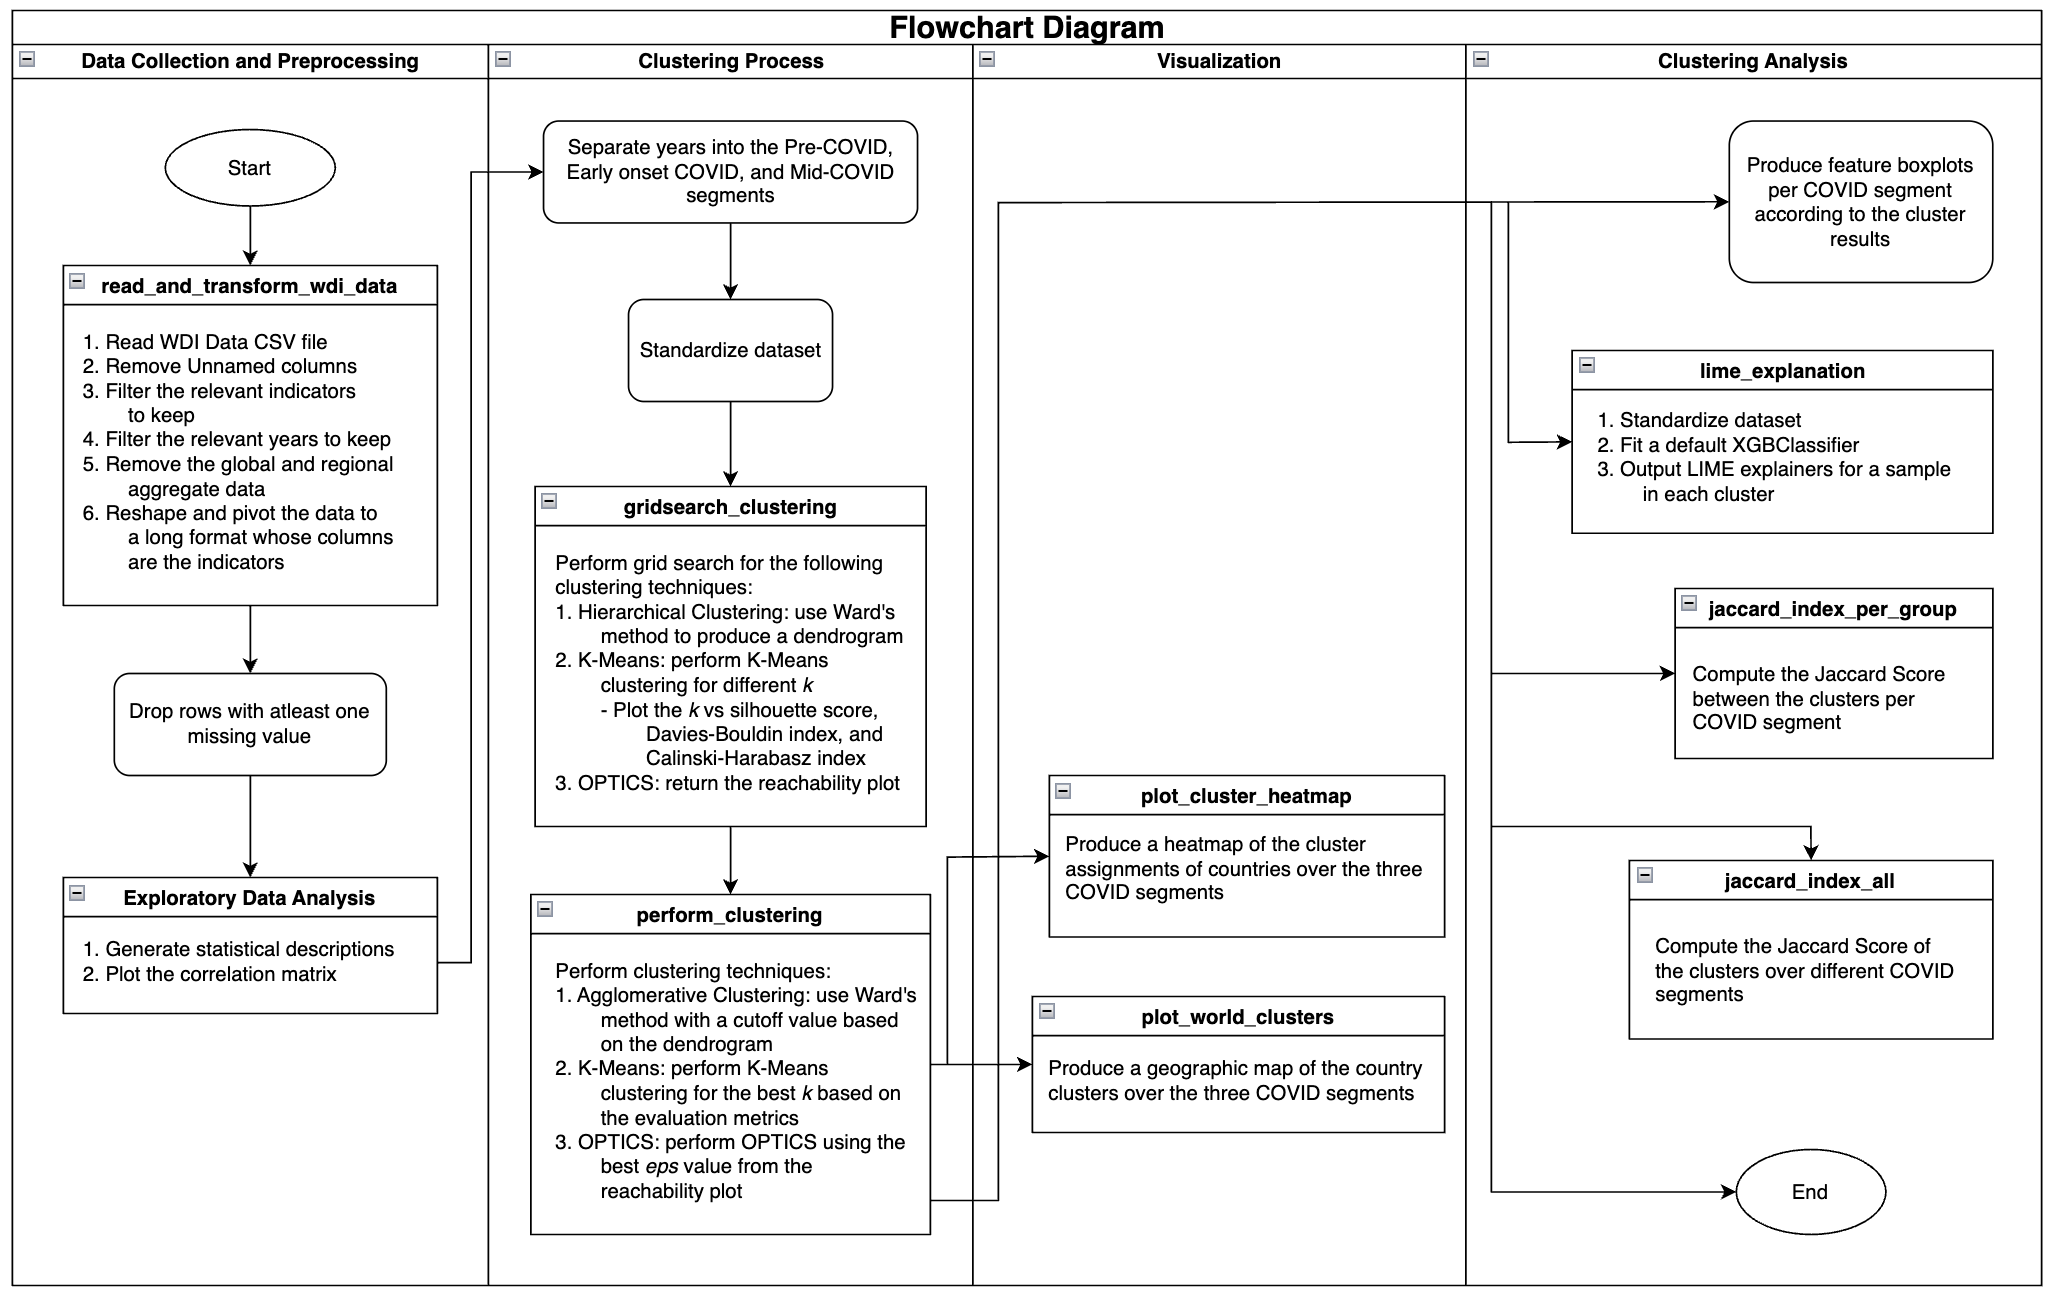

In [8]:
from IPython.display import Image
Image("flowchart.png")

### Data Source

The World Development Indicators (WDI) served as the foundation of the exploration of the effects of the COVID-19 pandemic across countries. The WDI is a comprehensive compilation of internationally comparable development statistics compiled by the World Bank Group. This database contains approximately 1400 time series indicators, covering 217 economies and more than 40 country groups. The indicators have data spanning 50 years, thus, providing solid pre-pandemic baselines. 

The WDI draws from officially recognized national statistical systems and international organizations. The World Bank Group employs several systems and statistical methodologies to compile data in the WDI. These methods are used to ensure consistency, comparability, and reliability across countries and periods.  

The WDI database organizes data across multiple themes, spanning different facets of an economy to build a complete feature aggregate of each economy. These themes include: 

- Poverty and Inequality - measures on poverty, prosperity, consumption, and income distribution 
- People - population dynamics, education, labor, health, and gender 
- Environment - agriculture, climate change, energy, biodiversity, water, and sanitation 
- Economy - growth, economic structure, savings, labor, and productivity 
- States and Markets - business, stock markets, military, communications, transport, and technology 

In order to efficiently and systematically narrow down the dataset, a subset of the indicators have been hand-picked based on the World Bank Group’s report entitled *The World Bank Group’s Early Support to Addressing the COVID-19 Economic Response. April 2020—June 2021. An Early-Stage Evaluation*. The report makes use of list of sectors with corresponding indicators. Of these indicators, a subset was taken for those with available data points for the 3 time periods relevant to the analysis.  

These indicators are as follows:

| Indicator | Definition |
| --- | --- |
| Agriculture, forestry, and fishing, value added (% of GDP) | Agriculture, forestry, and fishing corresponds to ISIC divisions 1-3 and includes forestry, hunting, and fishing, as well as cultivation of crops and livestock production. Value added is the net output of a sector after adding up all outputs and subtracting intermediate inputs. It is calculated without making deductions for depreciation of fabricated assets or depletion and degradation of natural resources. The origin of value added is determined by the International Standard Industrial Classification (ISIC), revision 4. Note: For VAB countries, gross value added at factor cost is used as the denominator. |
| Current health expenditure (% of GDP) | Level of current health expenditure expressed as a percentage of GDP.  Estimates of current health expenditures include healthcare goods and services consumed during each year. This indicator does not include capital health expenditures such as buildings, machinery, IT and stocks of vaccines for emergency or outbreaks. |
| Domestic general government health expenditure (% of GDP)  | Public expenditure on health from domestic sources as a share of the economy as measured by GDP. |
| Domestic general government health expenditure (% of general government expenditure) | Public expenditure on health from domestic sources as a share of total public expenditure.  It indicates the priority of the government to spend on health from own domestic public resources. |
| Domestic private health expenditure (% of current health expenditure)  | Share of current health expenditures funded from domestic private sources.  Domestic private sources include funds from households, corporations and non-profit organizations. Such expenditures can be either prepaid to voluntary health insurance or paid directly to healthcare providers. |
| Exports of goods and services (% of GDP) | Exports of goods and services represent the value of all goods and other market services provided to the rest of the world. They include the value of merchandise, freight, insurance, transport, travel, royalties, license fees, and other services, such as communication, construction, financial, information, business, personal, and government services. They exclude compensation of employees and investment income (formerly called factor services) and transfer payments. |
| Foreign direct investment, net inflows (% of GDP)  | Foreign direct investment are the net inflows of investment to acquire a lasting management interest (10 percent or more of voting stock) in an enterprise operating in an economy other than that of the investor. It is the sum of equity capital, reinvestment of earnings, other long-term capital, and short-term capital as shown in the balance of payments. This series shows net inflows (new investment inflows less disinvestment) in the reporting economy from foreign investors, and is divided by GDP.  |
| GDP growth (annual %)  | Annual percentage growth rate of GDP at market prices based on constant local currency. Aggregates are based on constant 2015 prices, expressed in U.S. dollars. GDP is the sum of gross value added by all resident producers in the economy plus any product taxes and minus any subsidies not included in the value of the products. It is calculated without making deductions for depreciation of fabricated assets or for depletion and degradation of natural resources.  |
| Gross capital formation (% of GDP)  | Gross capital formation (formerly gross domestic investment) consists of outlays on additions to the fixed assets of the economy plus net changes in the level of inventories. Fixed assets include land improvements (fences, ditches, drains, and so on); plant, machinery, and equipment purchases; and the construction of roads, railways, and the like, including schools, offices, hospitals, private residential dwellings, and commercial and industrial buildings. Inventories are stocks of goods held by firms to meet temporary or unexpected fluctuations in production or sales, and "work in progress." According to the 1993 SNA, net acquisitions of valuables are also considered capital formation.  |
| Imports of goods and services (% of GDP)  | Imports of goods and services represent the value of all goods and other market services received from the rest of the world. They include the value of merchandise, freight, insurance, transport, travel, royalties, license fees, and other services, such as communication, construction, financial, information, business, personal, and government services. They exclude compensation of employees and investment income (formerly called factor services) and transfer payments. |
| Labor force participation rate, total (% of total population ages 15-64) (modeled ILO estimate)  | Labor force participation rate is the proportion of the population ages 15-64 that is economically active: all people who supply labor for the production of goods and services during a specified period. |
| Manufacturing, value added (% of GDP)  | Manufacturing refers to industries belonging to ISIC divisions 15-37. Value added is the net output of a sector after adding up all outputs and subtracting intermediate inputs. It is calculated without making deductions for depreciation of fabricated assets or depletion and degradation of natural resources. The origin of value added is determined by the International Standard Industrial Classification (ISIC), revision 3. Note: For VAB countries, gross value added at factor cost is used as the denominator. |
| Personal remittances, received (% of GDP) | Personal remittances comprise personal transfers and compensation of employees. Personal transfers consist of all current transfers in cash or in kind made or received by resident households to or from nonresident households. Personal transfers thus include all current transfers between resident and nonresident individuals. Compensation of employees refers to the income of border, seasonal, and other short-term workers who are employed in an economy where they are not resident and of residents employed by nonresident entities. Data are the sum of two items defined in the sixth edition of the IMF's Balance of Payments Manual: personal transfers and compensation of employees. |
| Population density (people per sq. km of land area)  | Population density is midyear population divided by land area in square kilometers. Population is based on the de facto definition of population, which counts all residents regardless of legal status or citizenship--except for refugees not permanently settled in the country of asylum, who are generally considered part of the population of their country of origin. Land area is a country's total area, excluding area under inland water bodies, national claims to continental shelf, and exclusive economic zones. In most cases the definition of inland water bodies includes major rivers and lakes. |
| School enrollment, primary (% gross)  | Gross enrollment ratio is the ratio of total enrollment, regardless of age, to the population of the age group that officially corresponds to the level of education shown. Primary education provides children with basic reading, writing, and mathematics skills along with an elementary understanding of such subjects as history, geography, natural science, social science, art, and music. |
| Self-employed, total (% of total employment) (modeled ILO estimate)  | Self-employed workers are those workers who, working on their own account or with one or a few partners or in cooperative, hold the type of jobs defined as a "self-employment jobs." i.e. jobs where the remuneration is directly dependent upon the profits derived from the goods and services produced. Self-employed workers include four sub-categories of employers, own-account workers, members of producers' cooperatives, and contributing family workers. |
| Services, value added (% of GDP) | Services correspond to ISIC divisions 50-99 and they include value added in wholesale and retail trade (including hotels and restaurants), transport, and government, financial, professional, and personal services such as education, health care, and real estate services. Also included are imputed bank service charges, import duties, and any statistical discrepancies noted by national compilers as well as discrepancies arising from rescaling. Value added is the net output of a sector after adding up all outputs and subtracting intermediate inputs. It is calculated without making deductions for depreciation of fabricated assets or depletion and degradation of natural resources. The industrial origin of value added is determined by the International Standard Industrial Classification (ISIC), revision 3 or 4. |
| Unemployment, total (% of total labor force) (modeled ILO estimate)  | Unemployment refers to the share of the labor force that is without work but available for and seeking employment. |

The World Bank's approach to economic response measurement emphasizes both immediate indicators of economic distress and longer-term metrics of structural vulnerability and recovery capacity, providing a comprehensive framework for assessing how countries navigated the economic challenges of the COVID-19 pandemic. 

### Data Collection and Preprocessing

The methodology begins with data collection and preprocessing, where the WDI dataset is, first, cleaned by removing unnamed columns and filtering relevant indicators and years. The subset of indicators relevant to the study is manually selected based on economic, health, and social factors as suggested by a study performed by the World Bank Group (see Data Source section). The dataset is then filtered to retain only the years corresponding to the three defined COVID-19 periods: Pre-COVID (2019), Early onset COVID (2020), and Mid-COVID (2021). Aggregated data points representing global, regional, or income-based groups (e.g., “World,” “High Income,” “Sub-Saharan Africa”) are removed to ensure only individual country data is used. The dataset is, then, transformed into a long format, where each row corresponds to a country-year combination, with columns representing the selected indicators. this study added a completeness check for the columns wherein columns that have at least $70%$ missing values are removed. Countries with missing values in at least one indicator for at least one year are also completely removed from the dataset to ensure that clustering is based on complete and comparable information.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans, AgglomerativeClustering, OPTICS
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import geopandas as gpd
import xgboost
import lime
import lime.lime_tabular
import shap
from sklearn.metrics import jaccard_score

In [14]:
def read_and_transform_wdi_data(
    file_path='WDICSV.csv',
    indicators_dict=None,
    years=None,
    exclude_countries=None
):
    """
    This function loads WDI data, filters it based on specified indicators and years, 
    removes global aggregates, excludes specified countries, reshapes the data to a 
    long format, and pivots the table for easier analysis. It also removes
    columns with the number of missing values above the threshold.

    Keyword Arguments:
        file_path (str, optional): 
            Path to the CSV file containing WDI data. Defaults to 'WDICSV.csv'.
        indicators_dict (dict, optional): 
            A dictionary specifying indicator categories and their corresponding 
            indicator codes. If None, a default set of policy indicators is used.
        years (list of int, optional): 
            A list of years to retain in the dataset. If None, all available years are included.
        exclude_countries (list of str, optional): 
            A list of country names to exclude from the dataset. If None, no countries are excluded.

    Returns:
        pd.DataFrame: 
            A transformed DataFrame where each row represents a country and year, with 
            indicator values as separate columns.
    """  
    df = pd.read_csv(file_path)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # Default indicator dictionary
    if indicators_dict is None:
        indicators_dict = {
            # "Policy Indicators": [
            #     'IQ.CPA.STRC.XQ',
            #     'IQ.CPA.PROT.XQ',
            #     'IQ.CPA.MACR.XQ',
            #     'IQ.CPA.FISP.XQ',
            #     'IQ.CPA.ECON.XQ',
            #     'IQ.CPA.TRAD.XQ',
            #     'IQ.CPA.PUBS.XQ',
            #     'IQ.CPA.PADM.XQ',
            #     'IQ.CPA.GNDR.XQ',
            #     'IQ.CPA.ENVR.XQ',
            #     'IQ.CPA.SOCI.XQ',
            #     'IQ.CPA.PROP.XQ',
            #     'IQ.CPA.FINS.XQ',
            #     'IQ.CPA.DEBT.XQ',
            #     'IQ.CPA.TRAN.XQ',
            #     'IQ.CPA.REVN.XQ',
            #     'IQ.CPA.PRES.XQ',
            #     'IQ.CPA.HRES.XQ',
            #     'IQ.CPA.FINQ.XQ',
            #     'IQ.CPA.BREG.XQ'
            # ]
            "Education Indicators": [
                "SE.SEC.NENR", "SE.SEC.ENRL.TC.ZS", "SE.XPD.CTOT.ZS", "SE.XPD.PRIM.ZS",
                "SE.XPD.SECO.ZS", "SE.XPD.TERT.ZS"
            ],
            "Health Indicators": [
                "SH.XPD.CHEX.GD.ZS", "SH.XPD.GHED.GD.ZS", "SH.MED.BEDS.ZS", 
                "SH.MED.PHYS.ZS", "SH.UHC.NOP2.ZS", "SH.XPD.GHED.CH.ZS", "SH.XPD.PVTD.CH.ZS"
            ],
            "Social Protection and Outcomes Indicators": [
                "SI.POV.LMIC", "SI.POV.MDIM", "SI.POV.GINI", "SL.UEM.TOTL.ZS", "HD.HCI.OVRL",
                "SE.TER.ENRR", "SL.EMP.SELF.ZS", "EN.POP.DNST", "SE.PRM.ENRR", 
                "SE.SEC.ENRR"
            ],
            "Public Finance Indicators": [
                "GC.DOD.TOTL.GD.ZS", 
                "DT.TDS.DPPG.GN.ZS", 
                "GC.TAX.TOTL.GD.ZS"
            ],
            "Monetary and Financial Systems Indicators": [
                "FB.BNK.CAPA.ZS", "FD.RES.LIQU.AS.ZS", "FB.AST.NPER.ZS", "FR.INR.RINR", 
                "FI.RES.TOTL.DT.ZS"
            ],
            "Economic Fitness Indicators": [
                "NY.GDP.MKTP.KD.ZG", "NE.GDI.TOTL.ZS", "NE.EXP.GNFS.ZS", "NE.IMP.GNFS.ZS", 
                "BX.KLT.DINV.WD.GD.ZS", "GC.XPN.TOTL.GD.ZS", "DT.DOD.DSTC.ZS", "BX.TRF.PWKR.DT.GD.ZS"
            ],
            "Industry Composition and Productivity Indicators": [
                "NV.AGR.TOTL.ZS", "NV.IND.MANF.ZS", "NV.SRV.TOTL.ZS", "SL.TLF.ACTI.ZS", 
                # "SL.TLF.ADVN.ZS"
            ]
        }

    relevant_indicators = [
        indicator for category in indicators_dict.values() for indicator in category]
    df_filtered = df[df['Indicator Code'].isin(relevant_indicators)]

    if years:
        selected_columns = ['Country Name', 'Country Code',
                            'Indicator Name', 'Indicator Code'] + [str(year) for year in years]
        df_filtered = df_filtered[selected_columns]

    df_filtered = df_filtered[~df_filtered["Country Name"].str.contains(
        "World", na=False)]
    if exclude_countries:
        df_filtered = df_filtered[~df_filtered["Country Name"].isin(
            exclude_countries)]

    df_melted = df_filtered.melt(id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
                                 var_name='Year',
                                 value_name='Value')

    df_pivoted = df_melted.pivot_table(index=['Country Name', 'Country Code', 'Year'],
                                       columns='Indicator Name',
                                       values='Value',
                                       aggfunc='first').reset_index()

    df_pivoted['Year'] = df_pivoted['Year'].astype(int)

    threshold = 0.7 * len(df_pivoted)
    df_pivoted = df_pivoted.dropna(axis=1, thresh=threshold)
    # country_nan_counts = df_pivoted.groupby(['Country Name', 'Country Code']).apply(lambda x: x.isna().sum())
    # countries_to_keep = country_nan_counts[country_nan_counts.le(1).all(axis=1)].index
    # df_cleaned = df_pivoted[df_pivoted.set_index(['Country Name', 'Country Code']).index.isin(countries_to_keep)]
    # df_cleaned = df_pivoted.copy()

    # def impute_missing_values(group):
    #     numeric_cols = group.columns.difference(['Country Name', 'Country Code', 'Year'])
    #     group[numeric_cols] = group[numeric_cols].apply(lambda col: col.fillna(col.mean()), axis=0)
    #     return group

    # df_imputed = df_cleaned.groupby(['Country Name', 'Country Code'], group_keys=False).apply(impute_missing_values)

    return df_pivoted

In [15]:
to_remove = ["Middle East & North Africa (excluding high income)", "Europe & Central Asia",
             "Latin America & the Caribbean (IDA & IBRD countries)", "Africa Eastern and Southern",
             "Low & middle income", "Sub-Saharan Africa", "Middle East & North Africa (IDA & IBRD countries)",
             "South Asia (IDA & IBRD)", "IDA total", "Least developed countries: UN classification",
             "Lower middle income", "Other small states", "Upper middle income", "Small states",
             "IDA blend", "Latin America & Caribbean", "Low income", "East Asia & Pacific (IDA & IBRD countries)",
             "IDA & IBRD total", "Heavily indebted poor countries (HIPC)", "Latin America & Caribbean (excluding high income)",
             "Middle income", "Sub-Saharan Africa (excluding high income)", "Middle East & North Africa",
             "Europe & Central Asia (IDA & IBRD countries)", "South Asia",
             "East Asia & Pacific", "Europe & Central Asia (excluding high income)",
             "Sub-Saharan Africa (IDA & IBRD countries)", "IDA only", "East Asia & Pacific (excluding high income)",
             "Africa Western and Central", "Pre-demographic dividend",
             "Early-demographic dividend", "Post-demographic dividend", "High income", "Late-demographic dividend",
             "Fragile and conflict affected situations", "IBRD only", "European Union", 
             "OECD members", "Central Europe and the Baltics", "Euro area"]
countries_df = read_and_transform_wdi_data(
    years=[2019, 2020, 2021], exclude_countries=to_remove)

In [16]:
def gridsearch_clustering(df, max_clusters=10, min_clusters=2, plots=None):
    """
    Performs a grid search over a range of cluster numbers to evaluate clustering performance 
    using hierarchical clustering, K-Means, and OPTICS.

    Arguments:
        df (pd.DataFrame): 
            A DataFrame where rows represent samples (e.g., countries) and columns represent features.
        max_clusters (int, optional): 
            The maximum number of clusters to evaluate for K-Means. Defaults to 10.
        min_clusters (int, optional): 
            The minimum number of clusters to evaluate for K-Means. Defaults to 2.
        plots (list, optional):
            A list specifying which plots to display. Options:
            - "dendrogram" for Hierarchical Clustering
            - "kmeans_metrics" for K-Means evaluation metrics
            - "optics" for OPTICS reachability plot
            Defaults to showing all plots if None.

    Visualization Outputs:
        - A hierarchical clustering dendrogram.
        - Line plots for K-Means evaluation metrics.
        - An OPTICS reachability plot.
    """    
    if plots is None:
        plots = ["dendrogram", "kmeans_metrics", "optics"]

    X = df.values

    # Hierarchical Clustering Dendrogram
    if "dendrogram" in plots:
        plt.figure(figsize=(10, 5))
        linkage_matrix = sch.linkage(X, method='ward')
        sch.dendrogram(linkage_matrix, labels=df.index, leaf_rotation=90)
        plt.title(f"Hierarchical Clustering Dendrogram", fontsize=16, weight='bold')
        plt.xlabel("Countries")
        plt.ylabel("Distance")
        plt.show()

    # Evaluate K-Means & Hierarchical Clustering
    if "kmeans_metrics" in plots:
        silhouette_scores = []
        db_scores = []
        ch_scores = []
        cluster_range = range(min_clusters, max_clusters + 1)

        for k in cluster_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X)

            silhouette_scores.append(silhouette_score(X, labels))
            db_scores.append(davies_bouldin_score(X, labels))
            ch_scores.append(calinski_harabasz_score(X, labels))

        # Plot Metrics for Cluster Evaluation
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 3, 1)
        plt.plot(cluster_range, silhouette_scores, marker='o')
        plt.title("Silhouette Score", fontsize=16, weight='bold')
        plt.xlabel("Number of Clusters")

        plt.subplot(1, 3, 2)
        plt.plot(cluster_range, db_scores, marker='o')
        plt.title("Davies-Bouldin Index", fontsize=16, weight='bold')
        plt.xlabel("Number of Clusters")

        plt.subplot(1, 3, 3)
        plt.plot(cluster_range, ch_scores, marker='o')
        plt.title("Calinski-Harabasz Index", fontsize=16, weight='bold')
        plt.xlabel("Number of Clusters")

        plt.show()

    # OPTICS Reachability Plot
    if "optics" in plots:
        optics = OPTICS(min_samples=len(df.columns), cluster_method="dbscan")
        optics.fit(X)

        plt.figure(figsize=(8, 5))
        plt.plot(optics.reachability_[optics.ordering_], ".-")
        plt.title(f"OPTICS Reachability Plot", fontsize=16, weight='bold')
        plt.xlabel("Data Points")
        plt.ylabel("Reachability Distance")
        plt.show()

In [17]:
def perform_clustering(df, hc_cutoff, kmeans_k, optics_eps):
    """
    Performs clustering on the given dataset using Agglomerative Clustering with Ward's method, K-Means, and OPTICS.

    Arguments:
        df (pd.DataFrame): 
            A DataFrame where rows represent samples and columns represent features.
        hc_cutoff (float): 
            The distance threshold for cutting the hierarchical clustering dendrogram.
        kmeans_k (int): 
            The number of clusters for K-Means clustering.
        optics_eps (float): 
            The maximum neighborhood distance parameter (`eps`) for OPTICS clustering.

    Returns:
        pd.DataFrame: 
            A copy of the input DataFrame with three additional columns:
            - `"Hierarchical Cluster"`: Cluster assignments from Hierarchical Clustering.
            - `"K-Means Cluster"`: Cluster assignments from K-Means.
            - `"OPTICS Cluster"`: Cluster assignments from OPTICS.
    """
    X = df.values

    # Hierarchical Clustering
    hc = AgglomerativeClustering(
        n_clusters=None, distance_threshold=hc_cutoff, linkage='ward')
    hc_labels = hc.fit_predict(X)

    # K-Means Clustering
    kmeans = KMeans(n_clusters=kmeans_k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)

    # OPTICS Clustering
    optics = OPTICS(min_samples=len(df.columns), eps=optics_eps, metric='minkowski')
    optics_labels = optics.fit_predict(X)

    df_clusters = df.copy()
    df_clusters["Hierarchical Cluster"] = hc_labels
    df_clusters["K-Means Cluster"] = kmeans_labels
    df_clusters["OPTICS Cluster"] = optics_labels

    return df_clusters

### Exploratory Data Analysis

Before clustering, an exploratory data analysis (EDA) is conducted to understand the dataset’s structure and relationships between indicators. This step includes generating descriptive statistics for each indicator to assess data distribution and variability and correlation analysis to identify multicollinearity between indicators, ensuring that redundant variables do not bias clustering outcomes.

In [19]:
countries_df.dropna(how='any', inplace=True, axis=0)

country_counts = countries_df['Country Name'].value_counts()
valid_countries = country_counts[country_counts == 3].index
countries_df = countries_df[countries_df['Country Name'].isin(valid_countries)]

In [20]:
countries_df.describe()

Indicator Name,Year,"Agriculture, forestry, and fishing, value added (% of GDP)",Current health expenditure (% of GDP),Domestic general government health expenditure (% of GDP),Domestic general government health expenditure (% of current health expenditure),Domestic private health expenditure (% of current health expenditure),Exports of goods and services (% of GDP),"Foreign direct investment, net inflows (% of GDP)",GDP growth (annual %),Gross capital formation (% of GDP),Imports of goods and services (% of GDP),"Labor force participation rate, total (% of total population ages 15-64) (modeled ILO estimate)","Manufacturing, value added (% of GDP)","Personal remittances, received (% of GDP)",Population density (people per sq. km of land area),"School enrollment, primary (% gross)","Self-employed, total (% of total employment) (modeled ILO estimate)","Services, value added (% of GDP)","Unemployment, total (% of total labor force) (modeled ILO estimate)"
count,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000
mean,2020.000000,8.372725,7.342364,4.428897,58.133449,36.357850,41.963004,7.431410,1.813503,24.762019,45.705058,68.759362,12.740257,4.938715,194.986546,101.776506,35.991458,56.904590,6.887096
std,0.817662,7.724971,2.882301,2.453373,19.526106,16.716365,30.304600,35.219207,6.148466,7.209967,25.583396,9.862384,5.636145,7.140706,732.599172,9.666186,24.705083,9.803776,4.869158
min,2019.000000,0.030726,2.194109,0.275985,9.933729,5.592620,5.119171,-101.833102,-20.805276,8.932299,13.006122,40.883000,0.752186,0.000000,2.098350,68.309860,0.397294,30.444736,0.100000
25%,2019.000000,2.175909,5.194582,2.442812,44.634681,23.121113,23.831126,1.062933,-1.782829,19.828635,27.806064,63.692500,8.862933,0.405383,40.089059,97.477635,14.519449,50.851520,3.683000
50%,2020.000000,6.041478,7.090000,4.260000,61.144302,34.550000,33.757084,2.357033,2.500000,23.575317,40.070839,69.018000,12.160055,2.071101,83.732832,100.308418,30.165412,56.629204,5.364000
75%,2021.000000,11.881236,9.380461,5.881626,73.172315,48.365562,49.448620,4.413577,5.560325,28.431536,57.029921,75.824000,15.953089,7.188763,140.312803,104.366276,51.621784,63.560587,8.496500
max,2021.000000,38.375580,18.756220,10.692574,94.407379,86.600000,213.222679,433.860897,31.725742,53.713554,179.918519,88.213000,34.576137,41.978794,7965.878492,151.726317,91.520729,80.118756,34.007000


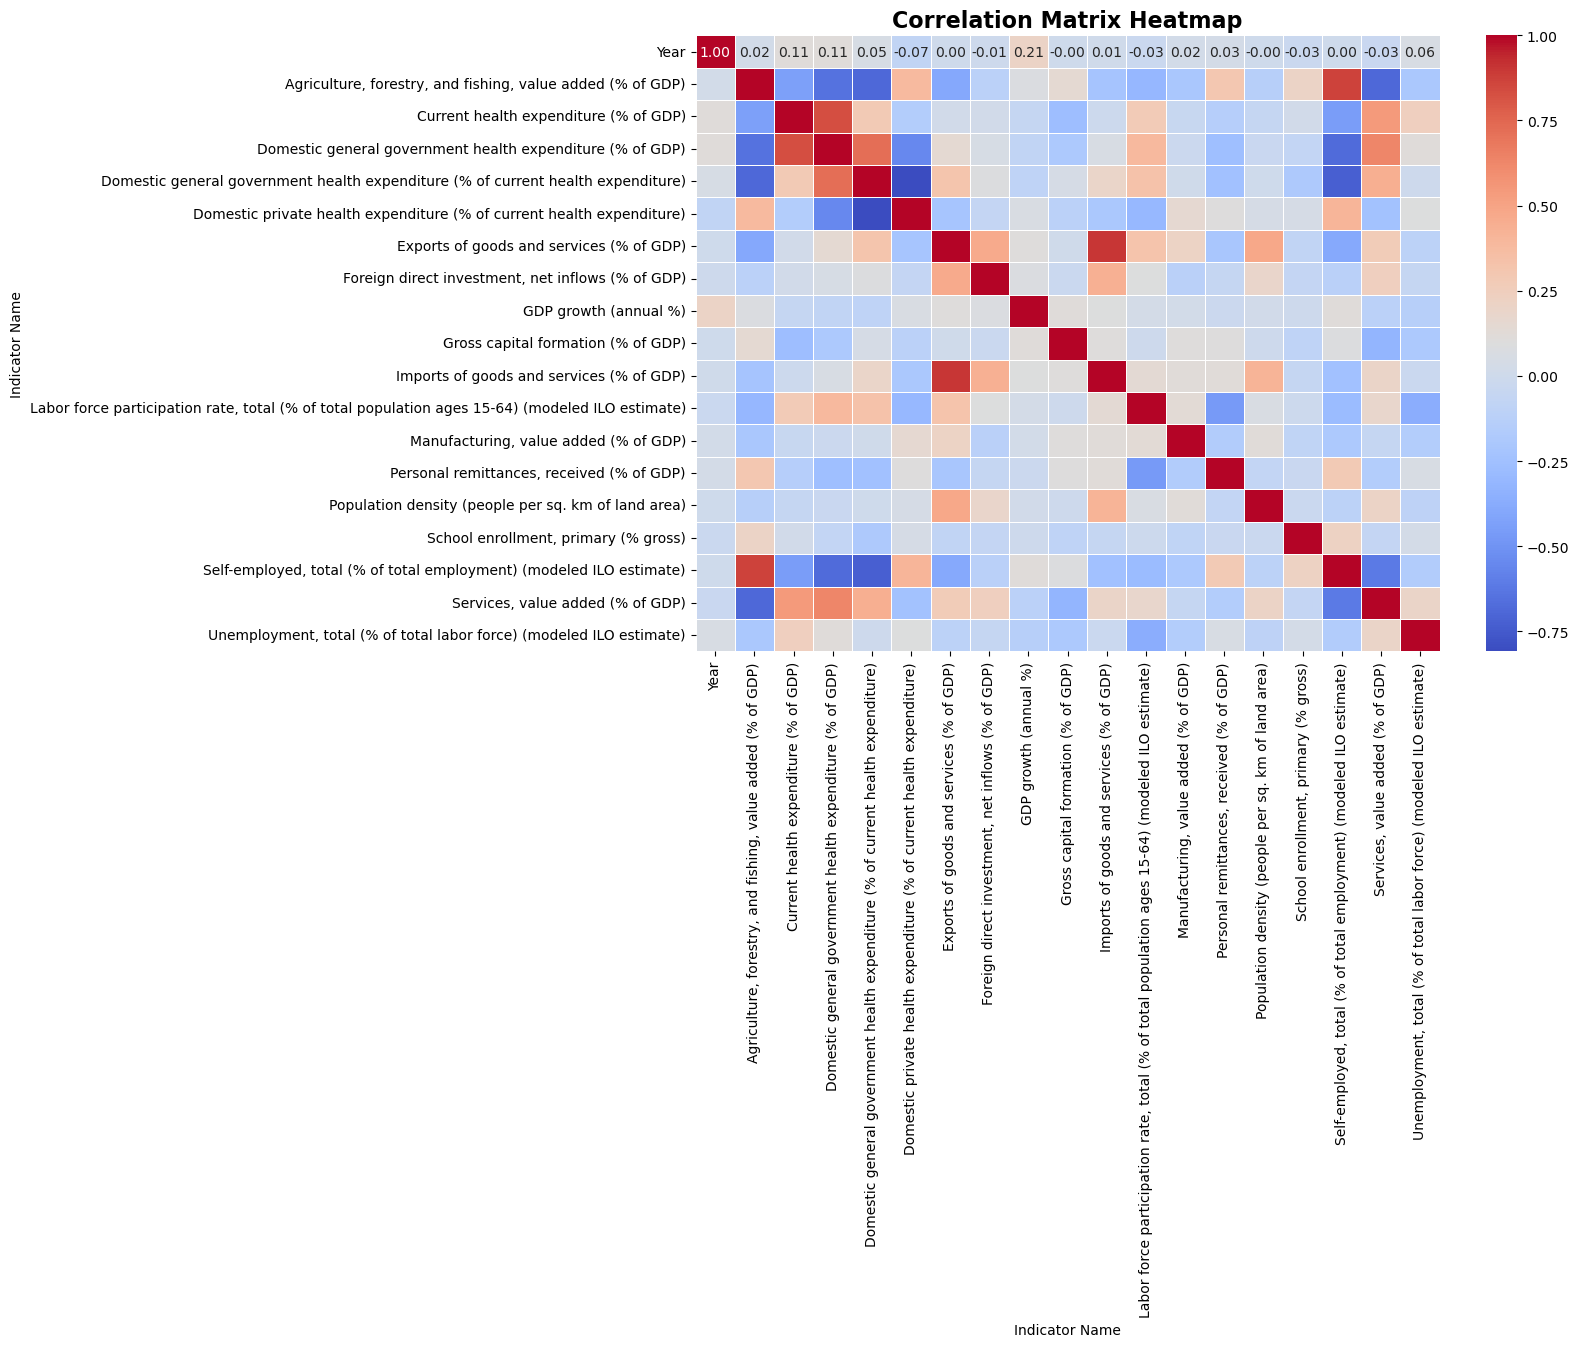

In [21]:
correlation_matrix = countries_df.iloc[:, 2:].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontsize=16, weight='bold')
plt.show()

### Clustering Strategies and Method Selection

The main clustering process starts with segmenting the dataset by COVID-19 periods and standardizing the features to ensure comparability across different scales. A grid search-based clustering strategy is employed using three clustering techniques: (1) Hierarchical Clustering using Ward’s method to generate a dendrogram, (2) K-Means Clustering with multiple $k$ values, evaluated using the silhouette score, Davies-Bouldin index, and Calinski-Harabasz index, and (3) OPTICS Clustering. Due to the small size of this project's dataset, Hierarchical Clustering is selected as the final method. The distance threshold for the agglomerative clustering for each COVID period is determined by analyzing the corresponding dendrogram’s structure. The results of the other clustering techniques are shown in the Appendix.

In [23]:
pre_covid = countries_df[countries_df['Year'] == 2019].drop(
    columns=['Year', 'Country Code']).set_index('Country Name')

In [24]:
standard_scaler = StandardScaler()
pre_covid_scaled = standard_scaler.fit_transform(pre_covid)

pca = PCA(n_components=2)
pre_covid_pca_viz = pca.fit_transform(pd.DataFrame(pre_covid_scaled))

pre_covid_scaled_df = pd.DataFrame(
    pre_covid_scaled, index=pre_covid.index, columns=pre_covid.columns)

For the pre-COVID dataset, this study chose a cutoff point of 18 because it resulted in four well-separated clusters with balanced gap distances between them. In hierarchical clustering, the gap distance refers to the separation between clusters in terms of linkage distances. A well-balanced clustering structure means that the distances between successive merges in the dendrogram are relatively uniform, avoiding scenarios where one cluster is disproportionately distant from the others. By selecting a cutoff at 18, this study ensured that the clustering solution captured meaningful groupings without forcing an arbitrary number of clusters or merging distinct groups prematurely.

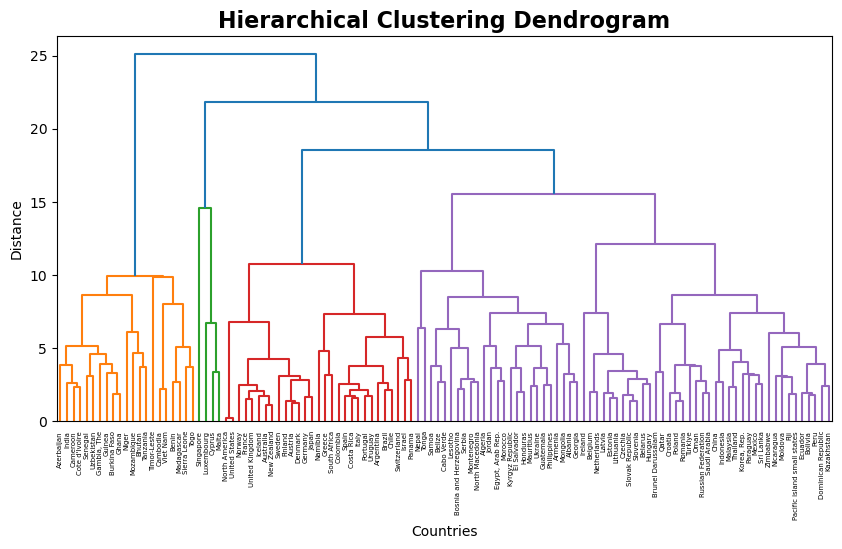

In [26]:
gridsearch_clustering(pre_covid_scaled_df, max_clusters=12, min_clusters=2, plots=["dendrogram"])

In [27]:
pre_covid_clusters = perform_clustering(
    pre_covid_scaled_df, hc_cutoff=18, kmeans_k=3, optics_eps=4)

In [28]:
covid = countries_df[countries_df['Year'] == 2020].drop(
    columns=['Year', 'Country Code']).set_index('Country Name')

In [29]:
standard_scaler = StandardScaler()
covid_scaled = standard_scaler.fit_transform(covid)

pca = PCA(n_components=2)
covid_pca_viz = pca.fit_transform(pd.DataFrame(covid_scaled))

covid_scaled_df = pd.DataFrame(
    covid_scaled, index=covid.index, columns=covid.columns)

Applying the same heuristic approach as in the pre-COVID group, this study identified a cutoff point of 20 for the early-onset COVID group, which resulted in three distinct clusters.

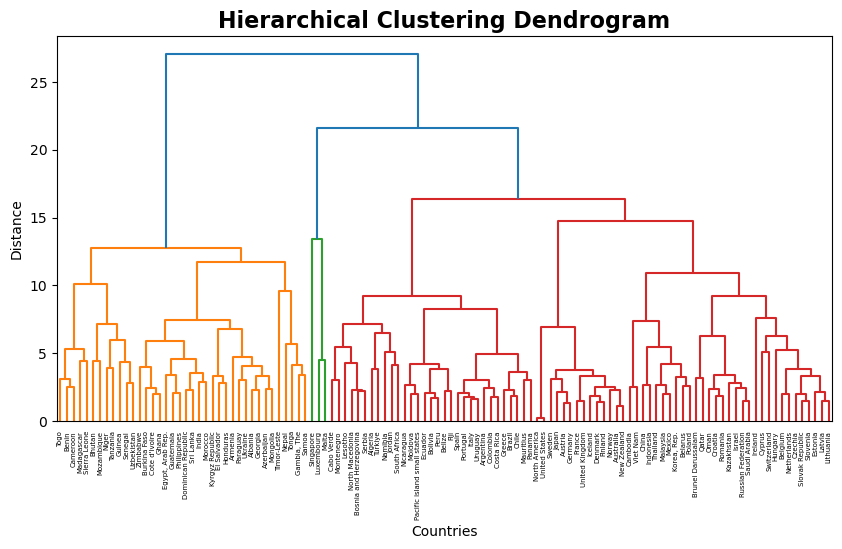

In [31]:
gridsearch_clustering(covid_scaled_df, max_clusters=12, min_clusters=2, plots=["dendrogram"])

In [32]:
covid_clusters = perform_clustering(
    covid_scaled_df, hc_cutoff=20, kmeans_k=3, optics_eps=5)

In [33]:
mid_covid = countries_df[countries_df['Year'] == 2021].drop(
    columns=['Year', 'Country Code']).set_index('Country Name')

In [34]:
standard_scaler = StandardScaler()
mid_covid_scaled = standard_scaler.fit_transform(mid_covid)

pca = PCA(n_components=2)
mid_covid_pca_viz = pca.fit_transform(pd.DataFrame(mid_covid_scaled))

mid_covid_scaled_df = pd.DataFrame(
    mid_covid_scaled, index=mid_covid.index, columns=mid_covid.columns)

Similarly, for the mid-COVID dataset, this study set the cutoff point to be 15, resulting in four clusters.

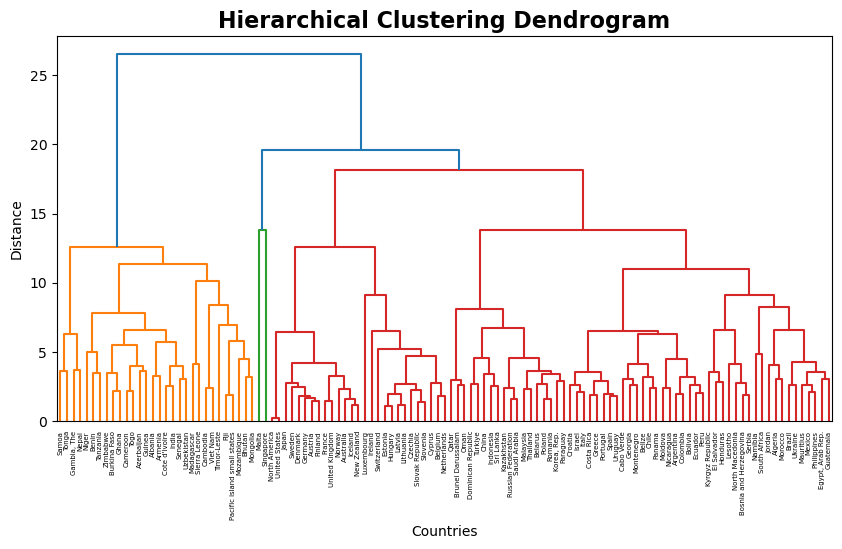

In [36]:
gridsearch_clustering(mid_covid_scaled_df, max_clusters=12, min_clusters=2, plots=["dendrogram"])

In [37]:
mid_covid_clusters = perform_clustering(
    mid_covid_scaled_df, hc_cutoff=15, kmeans_k=3, optics_eps=5)

### Visualization Techniques

To facilitate the interpretation of clustering results, two visualization techniques are employed: cluster assignment heatmaps and geographic cluster mapping. These methods allow for both temporal and spatial analysis of how countries are grouped across different COVID-19 periods.

1. **Cluster Assignment Heatmaps**
    
    A heatmap is plotted to track how countries are assigned to different clusters in the Pre-COVID, Early onset COVID, and Mid-COVID periods. This visualization helps in identifying whether countries remain in the same cluster over time or shift to different clusters due to changes in their economic and social indicators. The heatmap uses color-coded clusters, with rows representing countries and columns corresponding to COVID-19 periods. This format allows for an intuitive comparison of cluster membership across different periods, highlighting trends such as stable clusters (countries that remain in the same group) and transitional clusters (countries that switch between groups over time).

2. **Geographic Cluster Mapping**

    To analyze the spatial distribution of clusters, a world map is plotted where countries are color-coded according to their assigned clusters in each COVID-19 period. This visualization provides insights into regional patterns in cluster distribution, revealing potential geographic trends in how countries were affected by the pandemic. By comparing maps from different COVID-19 periods, it is possible to observe whether specific regions experienced cohesive shifts (e.g., neighboring countries transitioning into the same or different clusters) or if clustering patterns remain relatively stable across the pandemic. The geographic visualization enables a macro-level understanding of how development indicators evolved over time across different parts of the world.

### Clustering Analysis: Interpretation and Stability Assessment

To interpret the clustering results and gain deeper insights into the characteristics and stability of the identified clusters, this study conducts an in-depth analysis using three approaches: feature distribution analysis, LIME-based explainability, and Jaccard similarity analysis. These techniques allow the analysis to examine the defining attributes of each cluster, understand the key indicators influencing cluster assignments, and evaluate the consistency of clustering across different COVID-19 periods.

1. **Feature Distribution Analysis**

    To compare the characteristics of different clusters, this study generates boxplots of each indicator for each cluster within each COVID-19 period. Boxplots are particularly useful for visualizing the central tendency, spread, and distribution of key development indicators, allowing us to assess how economic and social factors vary across clusters. This analysis helps in identifying systematic differences between clusters, such as whether some clusters exhibit consistently higher or lower values for specific indicators. Additionally, boxplots highlight variability within clusters, helping determine whether certain clusters are more homogeneous (countries with similar indicator values) or heterogeneous (countries with greater internal variation). The feature distribution analysis provides a quantitative foundation for understanding the economic and social composition of each cluster.

2. **LIME-Based Explainability**

    To further investigate which features drive the cluster assignments, this study applies Local Interpretable Model-Agnostic Explanations (LIME) in conjunction with an XGBoost classifier. Since clustering is an unsupervised learning process and does not provide direct information about feature importance, this study leverages a supervised approach to infer which indicators contribute most to a country’s cluster assignment. The process involves the following steps:
    
    a. *Training an XGBoost Classifier*: this study uses the standardized dataset as input features and the assigned cluster labels as the target variable. An XGBoost classifier is trained using default parameters to predict a country’s cluster based on its development indicators.
    
    b. *Generating LIME Explanations*: this study applies LIME to produce local explanations for a representative sample of countries within each cluster. LIME perturbs the input data and fits an interpretable linear model locally to determine which features (indicators) have the greatest influence on the cluster assignment.

    This approach provides a post hoc explanation of clustering, revealing which indicators play the most significant role in differentiating clusters. By examining LIME results across different time periods, this study can also assess whether the importance of certain indicators changes as the pandemic progresses.

3. **Jaccard Similarity Analysis**

    To measure the stability of country clusters over time, this study computes the Jaccard Index, a metric that quantifies the similarity between two sets. The Jaccard Index is used in two ways:

    a. *Jaccard Index per Group*: this study computes the Jaccard similarity within each COVID-19 period to assess how well-defined and stable clusters are in that specific timeframe.

    b. *Jaccard Index Across Periods*: this study compares the clusters across different COVID-19 periods (Pre-COVID vs. Early COVID, Early COVID vs. Mid-COVID, and Pre-COVID vs. Mid-COVID) to evaluate how much the cluster compositions have changed over time.

    The Jaccard Index is calculated as:

$$ J(A, B) = \dfrac{|A \cap B|}{|A \cup B|} $$
    
where  $A$  and  $B$  represent the sets of country clusters being compared. A Jaccard Index close to 1 indicates that the clusters remain largely unchanged, suggesting stability in country groupings. Conversely, a low Jaccard Index suggests that countries have transitioned between clusters, indicating significant shifts in development indicators over time.

## Results and Discussion

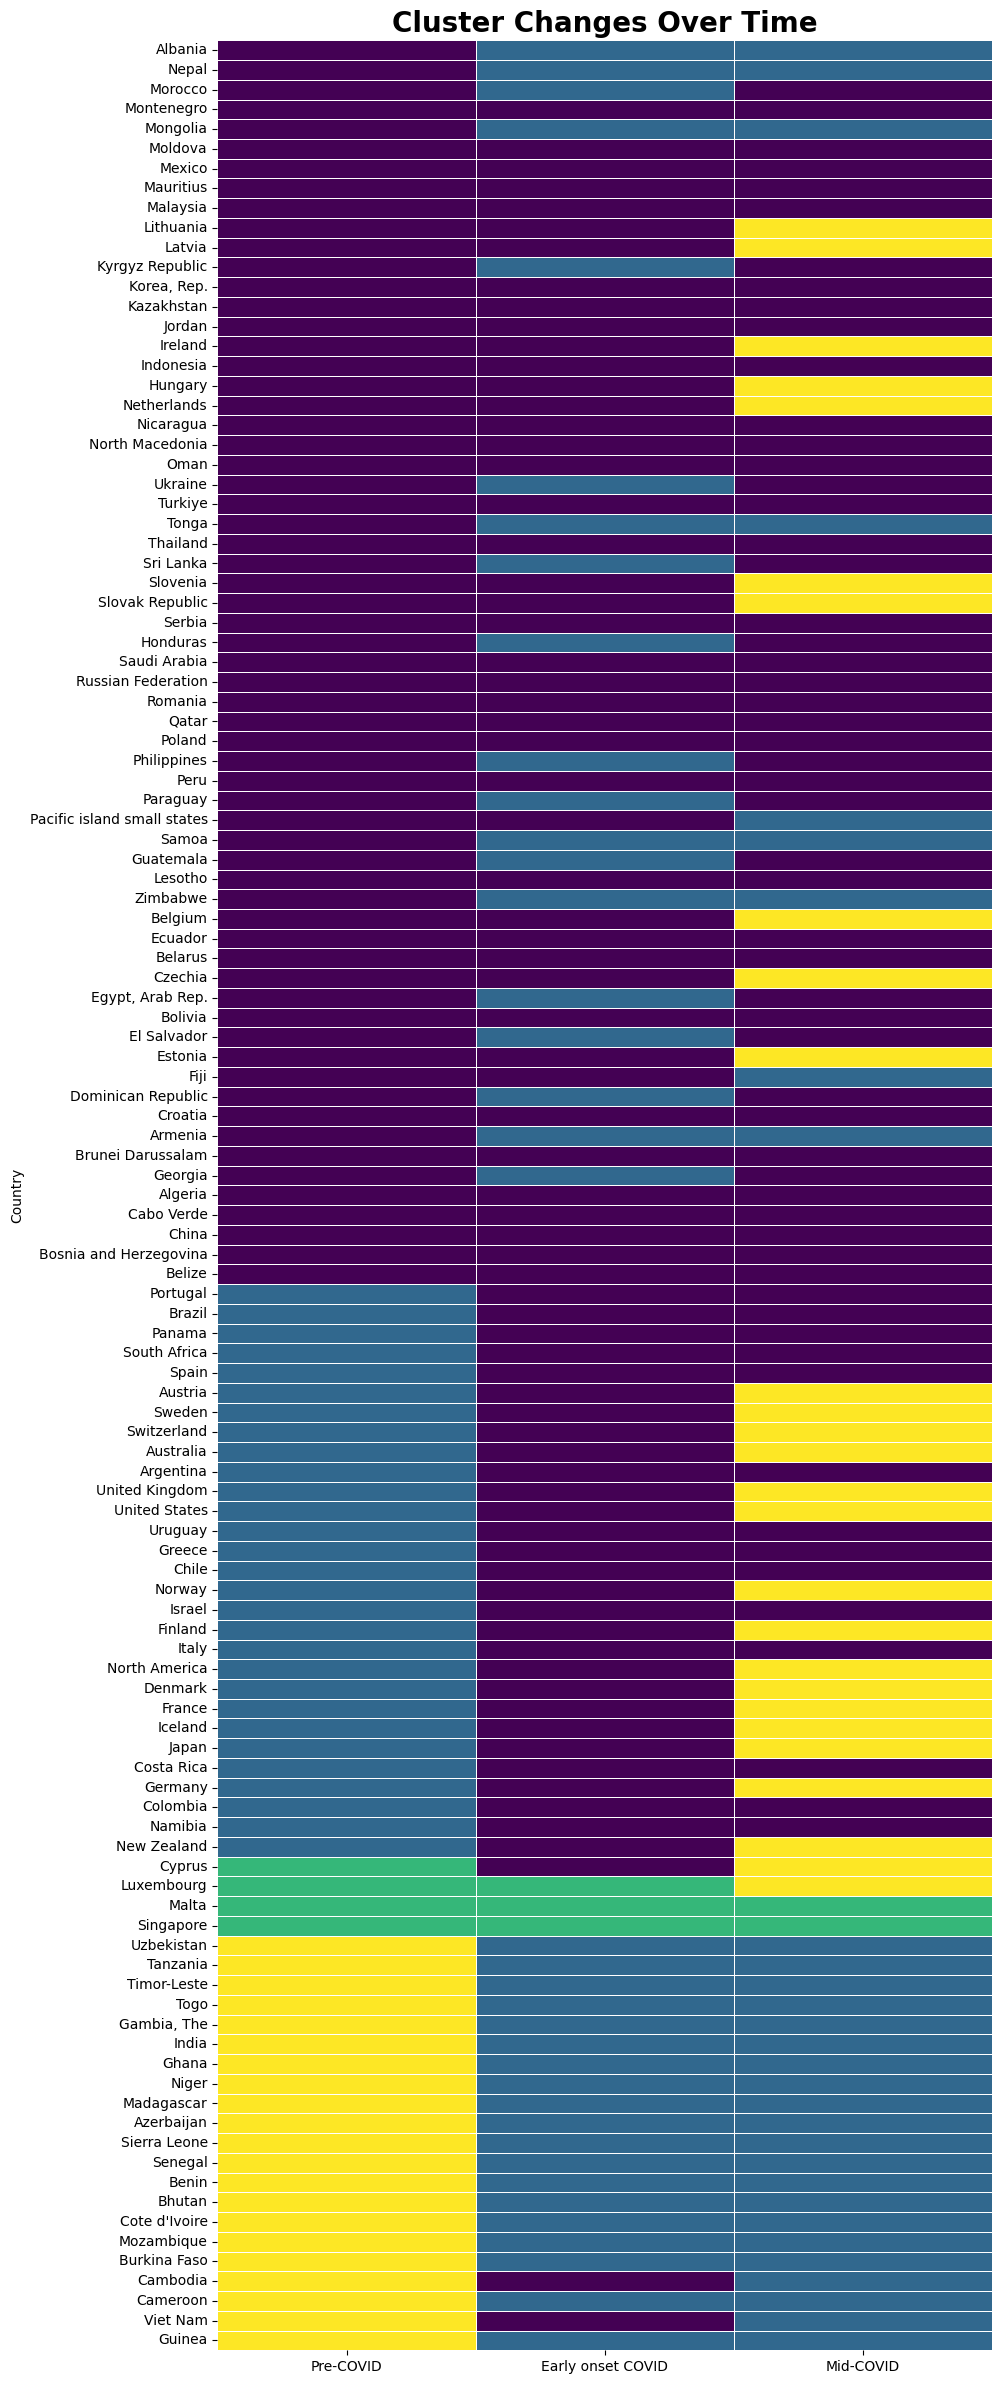

In [41]:
def plot_cluster_heatmap(pre_covid, covid, mid_covid, country_names):
    """
    This function constructs a DataFrame with cluster assignments for each country 
    across three time periods and plots a heatmap to visualize changes in hierarchical clustering assignments over 
    different time periods: Pre-COVID, COVID, and Mid-COVID.

    Arguments:
        pre_covid (pd.Series): 
            Cluster labels for the Pre-COVID period, indexed by country names.
        covid (pd.Series): 
            Cluster labels for the COVID period, indexed by country names.
        mid_covid (pd.Series): 
            Cluster labels for the mid-COVID period, indexed by country names.
        country_names (list of str): 
            A list of country names to be included in the heatmap.
    """    
    df = pd.DataFrame({
        "Country": country_names,
        "Pre-COVID": pre_covid,
        "Early onset COVID": covid,
        "Mid-COVID": mid_covid
    }).set_index("Country")

    df = df.sort_values(by="Pre-COVID")

    plt.figure(figsize=(10, 30))
    cmap = sns.color_palette("viridis", as_cmap=True)
    sns.heatmap(df, annot=False, cmap=cmap,
                linewidths=0.5, cbar=False)

    plt.title("Cluster Changes Over Time", weight='bold', fontsize=20)
    plt.show()

    return df


consolidated_df = plot_cluster_heatmap(pre_covid_clusters['Hierarchical Cluster'],
                     covid_clusters['Hierarchical Cluster'],
                     mid_covid_clusters['Hierarchical Cluster'],
                     pre_covid_clusters.index)

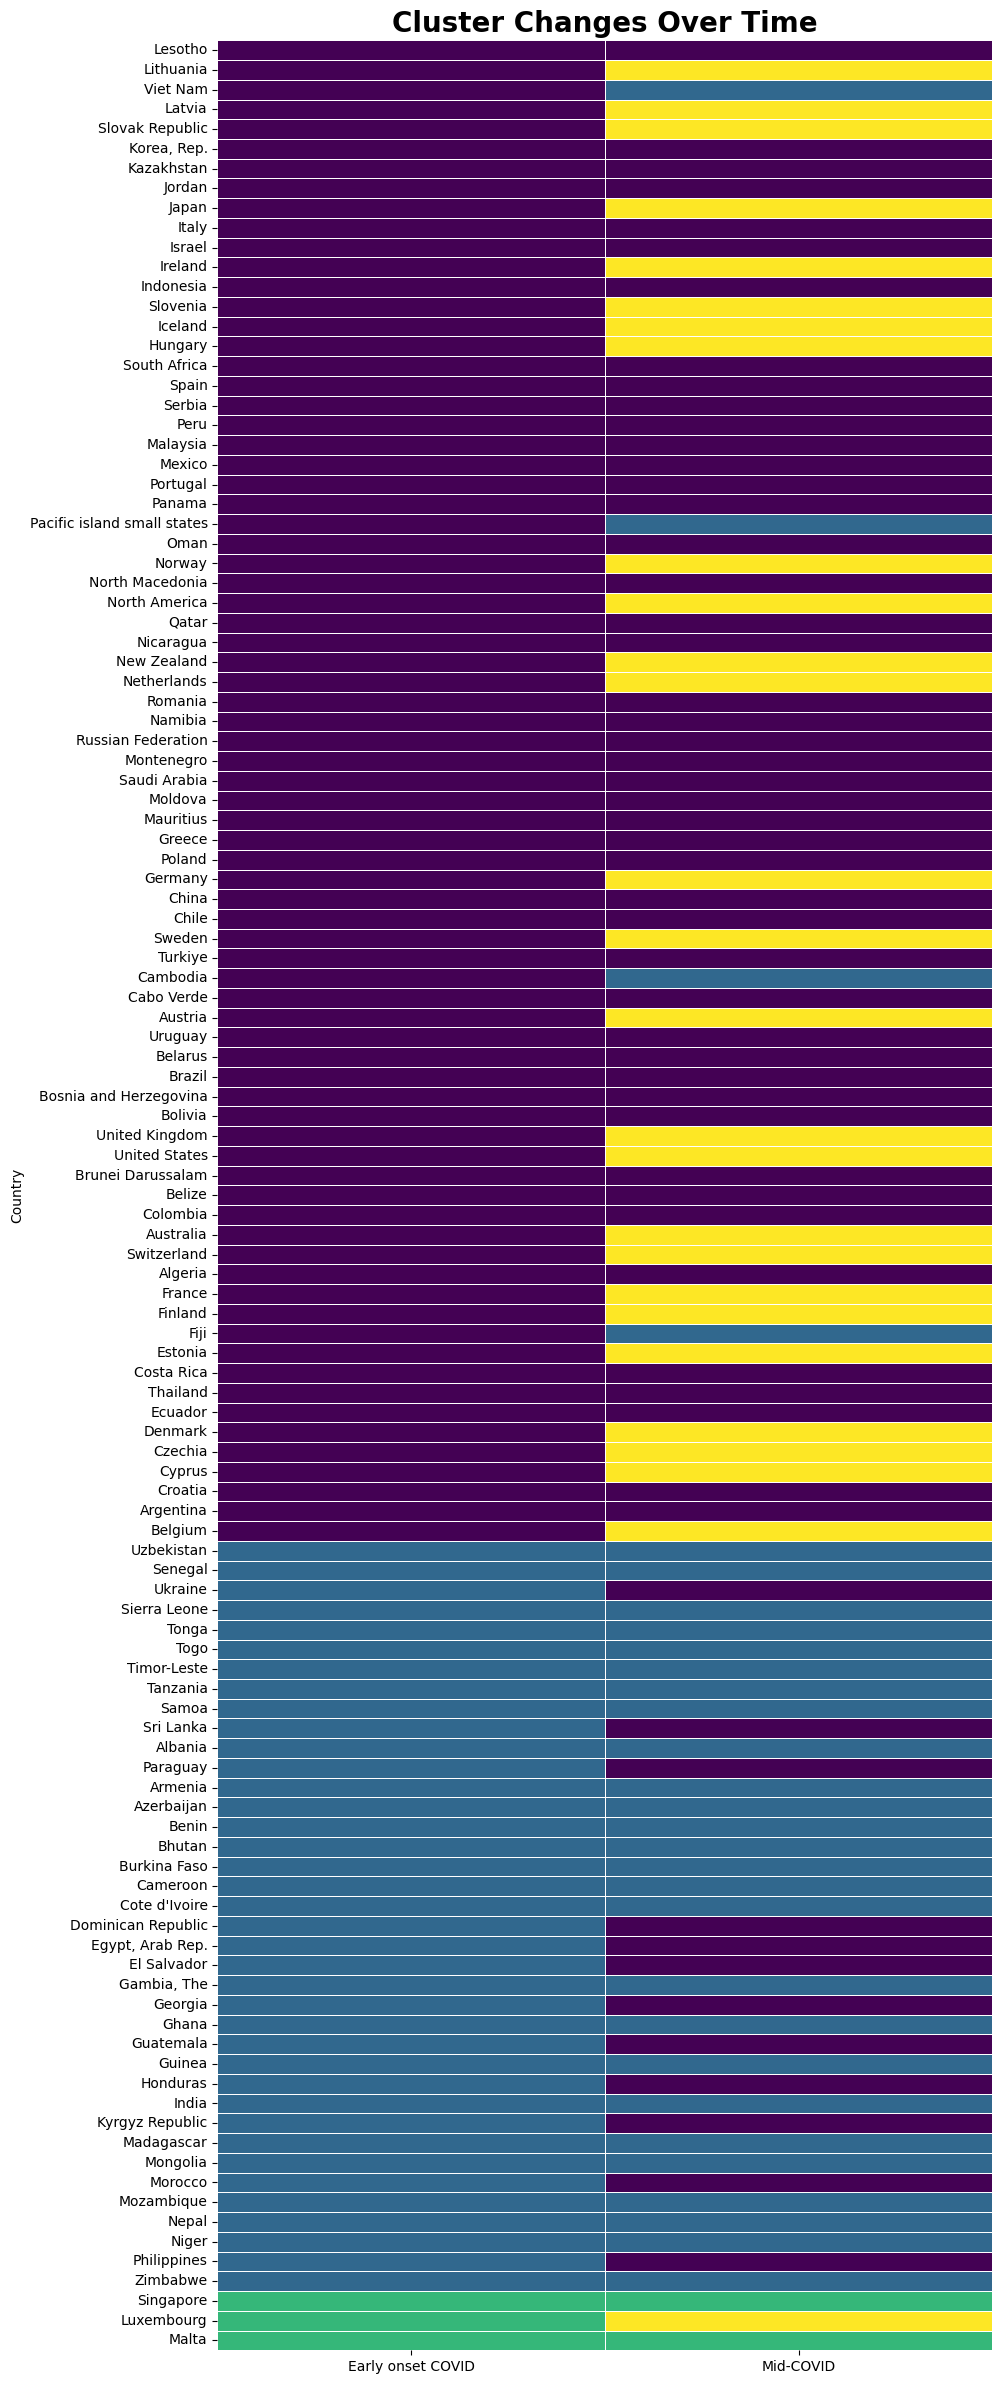

In [149]:
def plot_cluster_heatmap(covid, mid_covid, country_names):
    """
    This function constructs a DataFrame with Cluster assignments for each country
    across two time periods and plots a heatmap to visualize changes in hierarchical 
    clustering assignments: COVID and Mid-COVID.

    Arguments:
        covid (pd.Series):
            Cluster labels for the COVID period, indexed by country names.
        mid_covid (pd.Series):
            Cluster labels for the Mid-COVID period, indexed by country names.
        country_names (list of str):
            A list of country names to be included in the heatmap.
    """
    df = pd.DataFrame({
        "Country": country_names,
        "Early onset COVID": covid,
        "Mid-COVID": mid_covid
    }).set_index("Country")

    df = df.sort_values(by="Early onset COVID")  

    plt.figure(figsize=(10, 30))
    cmap = sns.color_palette("viridis", as_cmap=True)
    sns.heatmap(df, annot=False, cmap=cmap, linewidths=0.5, cbar=False)

    plt.title("Cluster Changes Over Time", weight='bold', fontsize=20)
    plt.show()

    return df

consolidated_df = plot_cluster_heatmap(
    covid_clusters['Hierarchical Cluster'],
    mid_covid_clusters['Hierarchical Cluster'],
    pre_covid_clusters.index
)


In [42]:
shapefile_path = "world-administrative-boundaries/world-administrative-boundaries.shp"
world = gpd.read_file(shapefile_path)

world["country_name"] = world["name"].str.lower().str.strip()

country_name_mapping = {
    "cabo verde": "cape verde",
    "gambia, the": "gambia",
    "lao PDR": "lao people's democratic republic",
    "micronesia, fed. sts.": "micronesia (federated states of)",
    "st. lucia": "saint lucia",
    "st. vincent and the grenadines": "saint vincent and the grenadines",
    "yemen, rep.": "yemen",
    "egypt, arab rep.": "egypt",
    "gambia, the": "gambia",
    "congo, dem. rep.": "democratic republic of the congo",
    "congo, rep.": "congo",
    "tanzania": "united republic of tanzania",
    "czechia": "czech republic",
    "north america": "canada",
    "korea, rep.": "republic of korea",
    "kyrgyz republic": "kyrgyzstan",
    "russian federation": "russian federation",
    "slovak republic": "slovakia",
    "turkiye": "turkey",
    "united kingdom": "u.k. of great britain and northern ireland",
    "united states": "united states of america",
    "viet nam": "vietnam",
    "cote d'ivoire": "côte d'ivoire",
    "bosnia and herzegovina": "bosnia & herzegovina",
    "moldova": "moldova, republic of",
    "tanzania": "united republic of tanzania",
    "north macedonia": "the former yugoslav republic of macedonia"
}

def standardize_names(df):
    """
    Standardizes country names in the DataFrame index by applying a predefined mapping 
    and ensuring consistent formatting.

    Arguments:
        df (pd.DataFrame): 
            A DataFrame where the index contains country names that need standardization.

    Returns:
        pd.DataFrame: 
            A DataFrame with standardized country names in the index.
    """    
    df.index = df.index.str.lower().str.strip()
    df = df.rename(index=country_name_mapping)
    df.index = df.index.str.lower().str.strip()
    return df

In [43]:
def plot_world_clusters(world_pre, world_covid, world_mid, column=["Pre-COVID", "Early onset COVID", "Mid-COVID"]):
    """
    This function generates a three-panel subplot where each map represents 
    the clustering of countries early a different time period. Countries 
    without cluster assignments are shown in light gray, while assigned clusters 
    are color-coded using the `viridis` colormap.

    Arguments:
        world_pre (gpd.GeoDataFrame): 
            A GeoDataFrame containing world geometries and cluster assignments 
            for the Pre-COVID period.
        world_covid (gpd.GeoDataFrame): 
            A GeoDataFrame containing world geometries and cluster assignments 
            for the COVID period.
        world_mid (gpd.GeoDataFrame): 
            A GeoDataFrame containing world geometries and cluster assignments 
            for the Mid-COVID period.
        column (str): 
            The name of the column containing cluster labels.

    Returns:
        None: Displays a matplotlib figure with three subplots showing cluster 
        distributions across the three time periods.
    """    
    fig, axes = plt.subplots(3, 1, figsize=(18, 20), sharex=True, sharey=True)

    titles = ["Pre-COVID Clusters", "Early onset COVID Clusters", "Mid-COVID Clusters"]
    datasets = [world_pre, world_covid, world_mid]
    columns = ["Pre-COVID", "Early onset COVID", "Mid-COVID"]

    for ax, gdf, title, column in zip(axes, datasets, titles, columns):
        gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
        gdf.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5)
        gdf[gdf[column].notna()].plot(column=column, cmap="viridis",
                                      edgecolor="black", linewidth=0.5, ax=ax)

        ax.set_title(title, fontsize=30, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

    plt.tight_layout()
    plt.show()

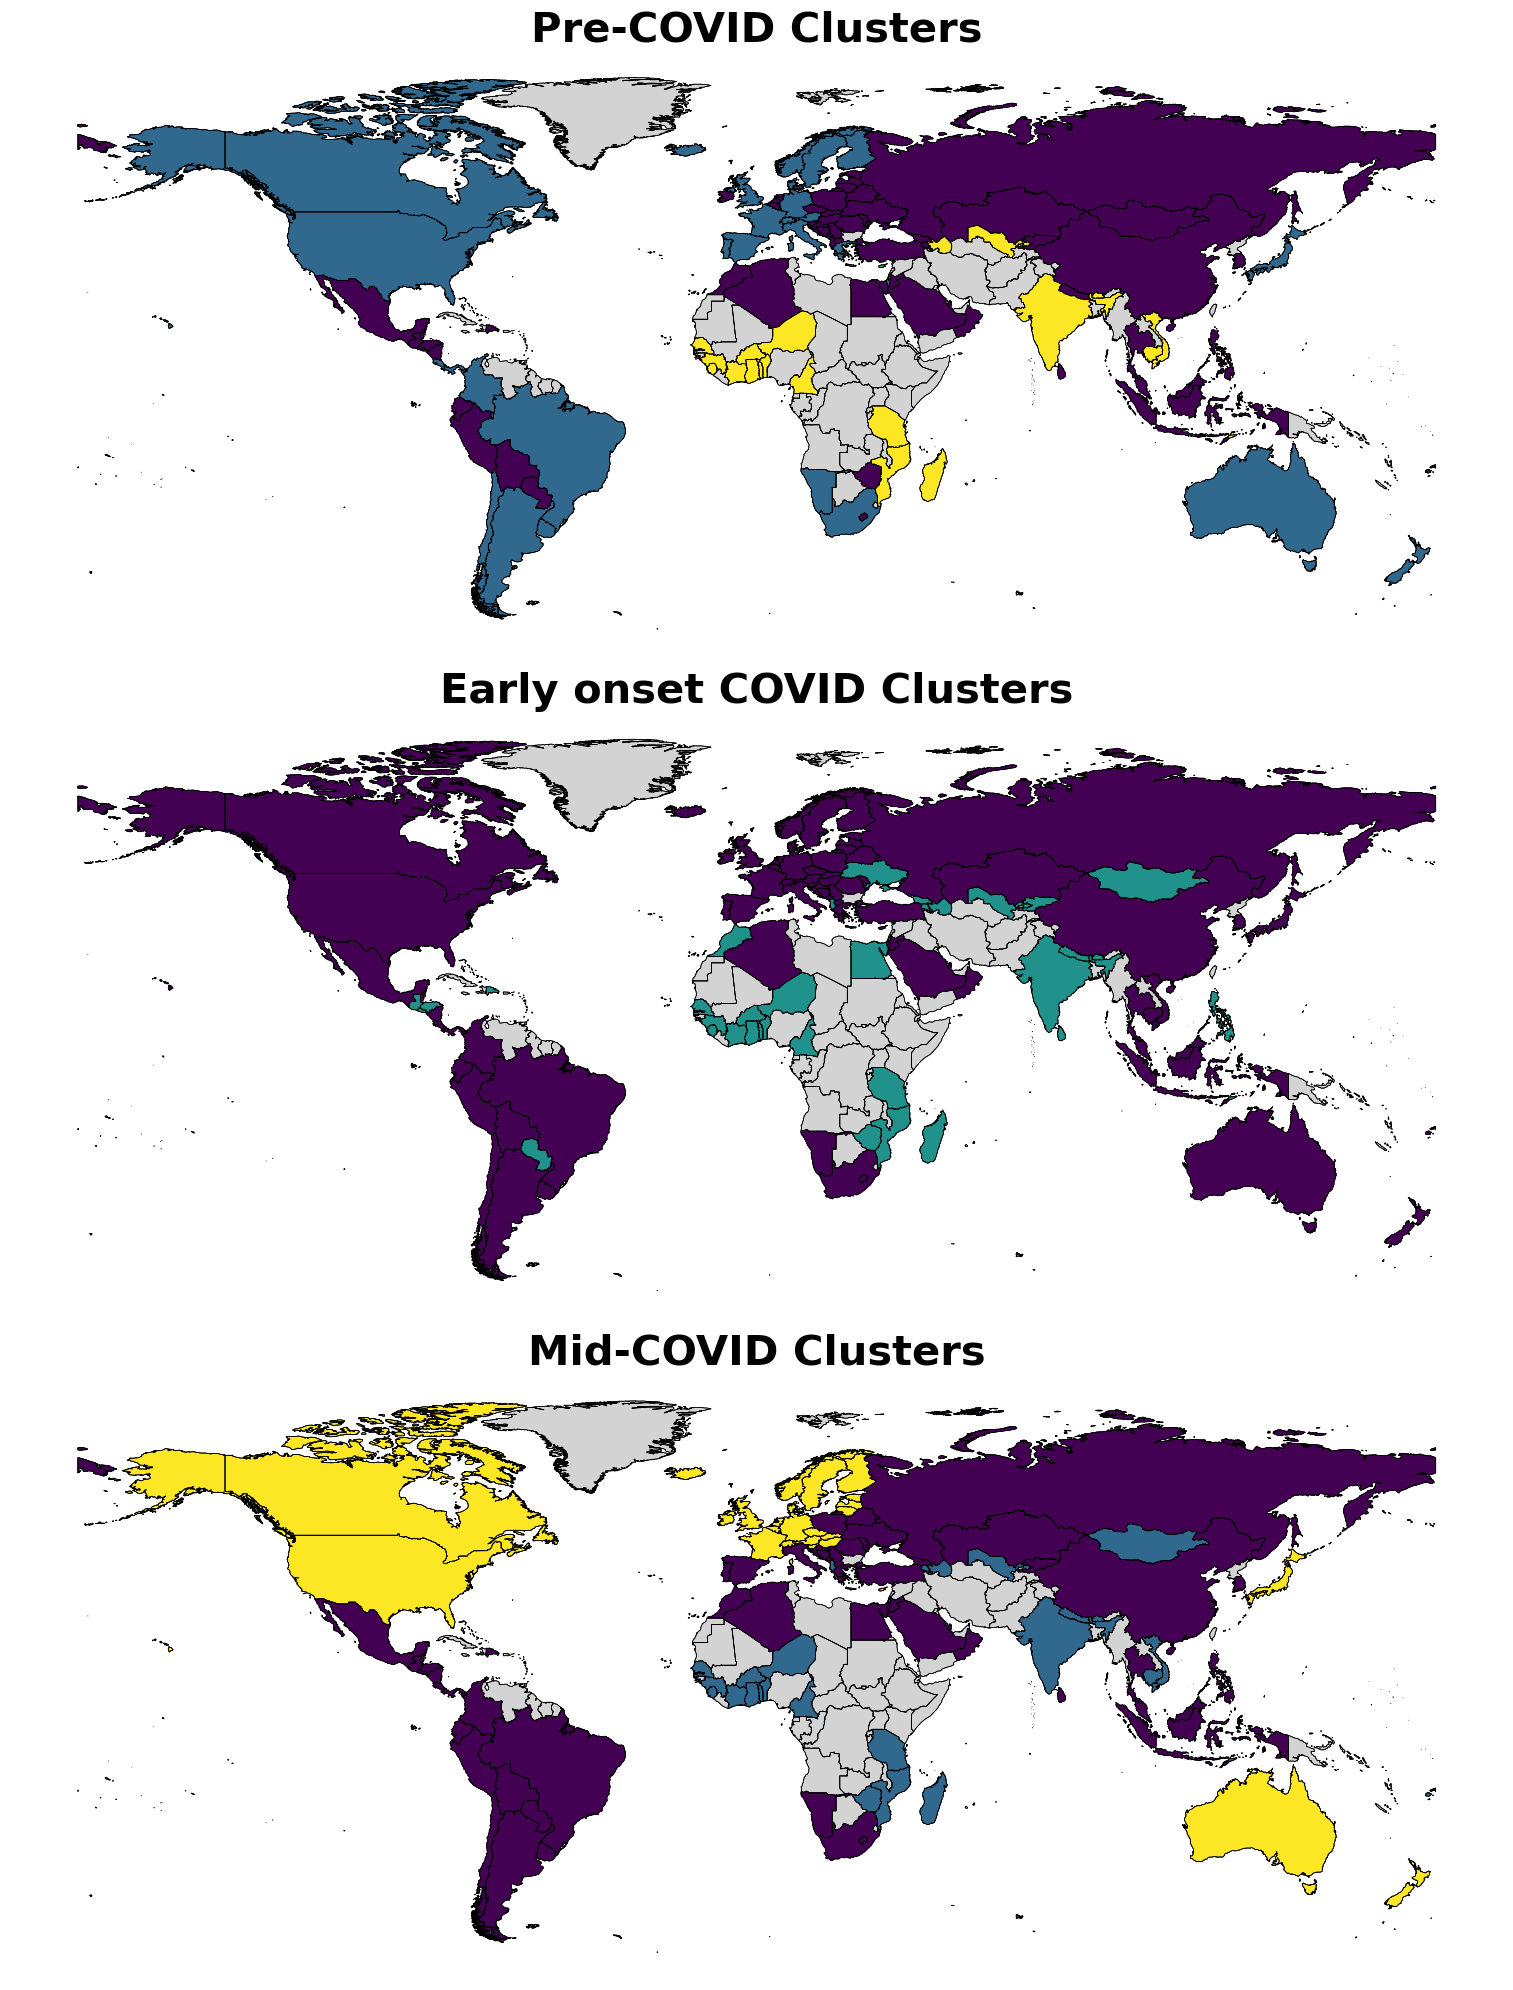

In [44]:
consolidated_df_standardized = standardize_names(consolidated_df)
consolidated_df_standardized_pre = consolidated_df_standardized['Pre-COVID'].copy()
consolidated_df_standardized_early = consolidated_df_standardized['Early onset COVID'].copy()
consolidated_df_standardized_mid = consolidated_df_standardized['Mid-COVID'].copy()

world_pre = world.merge(
    consolidated_df_standardized_pre, left_on="country_name", right_index=True, how="left")
world_covid = world.merge(
    consolidated_df_standardized_early, left_on="country_name", right_index=True, how="left")
world_mid = world.merge(
    consolidated_df_standardized_mid, left_on="country_name", right_index=True, how="left")

plot_world_clusters(world_pre, world_covid, world_mid)

The hierarchical clustering results provide a structured classification of countries based on selected economic, financial, health, and social indicators for three distinct years—Pre-COVID (2019), Early COVID (2020), and Mid-COVID (2021). The emphasis of this analysis is on how nations were grouped based on shared structural characteristics along with their health expenditures, government and private alike, and how these groupings evolved over time, rather than focusing on how countries responded to the pandemic per se. The latter requires a dataset that is specific to covid policy responses which goes beyond the WDI data used in this project. Nevertheless, tracking and analyzing the economic outcomes and fundamentals of the countries and how they evolved before and during covid merits exploratory interest on its own. In fact, the results reveal interesting significant patterns of stability, realignment, and transition providing valuable insights into underlying economic and developmental structures across the different periods.

One of the most critical findings is the presence of both stable and transitioning clusters. Countries such as Thailand, Malaysia, and Indonesia remained clustered together across all three years, suggesting that these nations have long-standing structural similarities in their economic and social frameworks that persisted regardless of external conditions. This stability suggests that, despite external global fluctuations, including the COVID-19 pandemic, financial crises, and shifts in global trade patterns, these nations exhibited a high degree of similarity that remained aligned over time, reinforcing their comparative positioning in global development rankings. Their shared clustering is not merely a reflection of income levels but is driven by a complex interplay of macroeconomic structures, trade dependencies, industrial composition. For instance, these economies share a hybrid economic structure, where manufacturing plays a substantial role specifically in electronics, semiconductors, automotive production, and industrial goods. 

Another interesting case is the clustering of Singapore and Malta which remained clustered together for all three years. One of the most striking similarities between Singapore and Malta is that they are both small but highly strategic economies, leveraging their geographical positioning to become key global trade and financial hubs. Their economic model is not based on natural resource wealth or vast domestic markets but rather on their ability to integrate seamlessly into global supply chains and facilitate international trade.

However, note that this is not a generalization for all the countries that remained clusteted in this grouping for all three years. This is an analytical characterization for some countries in the grouping consistent with the observed indicators and the plotted indicator distribuiton in the boxplots below. Indeed, based on these plots this study observed that the cluster where Thailand, Malaysia, and Indonesia remained grouped have a manufacturing sector median share that is more than the other clusters. Similary the cluster where Singapore and Malta remained grouped for all three years is characteristic of having the high exports and imports share, foreign direct investment, and services sector.

On the other hand, some countries exhibited high mobility between clusters, transitioning into different groups over the years. For this analysis it is important to point out that since the clustering was independently implemented for each year, the label 'cluster 0' in one year does not necessarily correspond to the same 'cluster 0' in other years. What this study is particularly interested in is whether or not a country is clustered with the same set countries, regardless of the cluster label, across the years of interest. The cluster labels themselves are simply used for identification purposes for ease of analysis and discussion.

The 63 countries in cluster 0 in 2019 was split into two new clusters in 2020. 2020 Cluster 0 contains 44 of which formed a new cluster with all of the 2019  Cluster 1 countries (e.g. United States, Japan, Germany, Australia, etc.).While the remaining 19 of which (e.g. Nepal, Sri Lanka, Philippines) were clustered together with most of the countries in 2019 cluster 3 (e.g. India, Timor-Leste, Uzbekistan, etc.). This pattern is particularly revealing as it points to a divergence within previously similar economies, resulting in one group integrating with high-income, resilient economies while another moved closer to structurally distinct, emerging economies.

One of the analytical insights that could be infered from this shift is that Cluster 0 in 2019 was not as homogenous as initially perceived. The split into two separate clusters in 2020 suggests that within this original grouping, there were latent differences in economic resilience and structural adaptability that only became fully visible when external pressures such as the COVID-19 pandemic and the global economic disruptions it broughtforth acted as a sorting mechanism. The 44 countries that merged with Cluster 0 in 2020 likely possessed more robust institutional frameworks, diversified economies, and stronger financial market depth, allowing them to realign with advanced economies like the U.S., Japan, Germany, United Kingdom, Spain, and Australia. On the other hand, the 19 countries that moved towards 2020’s Cluster 0 economies likely exhibited greater structural fragility, sectoral dependencies, or developmental similarities with lower-income and emerging economies. In fact, many of these economies rely heavily on tourism, remittances, or raw material exports, all of which were severely disrupted in 2020. Countries with high external revenue dependence saw sharper contractions and structural shifts, aligning them more closely with lower-income economies.

Lastly, it is also apparent in the results that while countries in the original 2019 Cluster 0 were split and merged into new cluster during the onset of the pandemic, many of these split countries eventually exhibited realignment to this original cluster in 2021. More specifically, 12 of the 19 countries (from 2019 Cluster 0) that were grouped in 2020 Cluster 1 eventually realigned with their original clustering in 2021 (Cluster 0). These countries include Philippines, Sri Lanka, Ukraine, Paraguay, Dominican Republic, Egypt, El Salvador, Georgia, Guatemala, Honduras, Kyrgyz Republic, and Morocco. Meanwhile the remaining 7 countries of the 19, continued diverging from their original 2019 cluster, and remained to be clustered with low income countries they were grouped with at the onset of the pandemic. These countries include Albania, Nepal, Mongolia, Tonga, Samoa. Armenia, and Zimbabwe.

This observation is suggestive of a temporary structural misalignment during the initial shock of the pandemic, rather than a permanent economic transformation. This shift highlights the resilience and adaptive capacity of these economies, demonstrating that their initial transition into a different cluster in 2020 was likely a result of short-term disruptions rather than deep-seated economic weaknesses. Conversely, the seven countries that remained in the more vulnerable cluster in 2021 suggest that their economic structures underwent more fundamental shifts, which prevented them from returning to their pre-pandemic classification. This divergence provides a powerful insight into the mechanisms of economic recovery and structural economic mobility in times of global crisis.

While not within the scope of the agnostic clustering method implemented in this project several key factors consistent with the data may explain the countries' ability to realign with their original cluster in 2021. Countries such as the Philippines, Egypt, and Ukraine implemented aggressive fiscal and monetary measures to stabilize their economies after the initial impact of the pandemic. Expanding social safety nets, providing economic stimulus packages, and securing international financial support may have helped these economies recover faster than those that remained in the weaker cluster in 2021. Ukraine, for example, introduced fiscal policies focused on macroeconomic stability and currency control, which likely played a role in restoring investor confidence. Similarly, Egypt continued its economic reform program while maintaining targeted social protection measures, which supported its economic realignment by 2021.

In contrast to the 12 countries that realigned with their 2019 Cluster 0 classification, the other seven countries which continued to remain in the more vulnerable cluster they had joined in 2020, is indicative that their economic structures underwent deeper, more lasting shifts, making it difficult for them to return to their pre-pandemic economic grouping/classification. The continued misalignment of these economies suggests that they lacked the fiscal capacity, institutional agility, or structural economic flexibility needed to recover at the same pace as the other 12 nations. Several critical factors likely contributed to their continued divergence such as those characteristic of havinga weaker institutional buffers and higher reliance on volatile economic sectors.For instance, countries such as Nepal, Tonga, and Samoa are heavily reliant on tourism and remittances, both of which suffered prolonged disruptions due to the pandemic. Unlike the remittance-based economies of Guatemala, El Salvador, and Honduras that rebounded quickly, these nations may have faced slower recovery due to greater dependence on international travel and external labor migration policies. 


### Feature Distribution Analysis

In [46]:
def merge_dataframes(world_gdf, clusters_df, df):
    """
    Merges multiple data sources to create a unified DataFrame containing geographic 
    information, clustering assignments, and additional data.

    Arguments:
        world_gdf (gpd.GeoDataFrame): 
            A GeoDataFrame containing world country shapes and geographic metadata, 
            including country names, regions, continents, and status information.
        clusters_df (pd.DataFrame): 
            A DataFrame containing country-wise cluster assignments from different 
            clustering methods (Hierarchical, K-Means, OPTICS).
        df (pd.DataFrame): 
            A DataFrame containing additional country-level attributes that need 
            to be merged.

    Returns:
        pd.DataFrame: 
            A merged DataFrame containing country names, geographic metadata, 
            clustering labels, and additional attributes.
    """    
    if clusters_df.index.name is not None:
        clusters_df = clusters_df.reset_index()
    if df.index.name is not None:
        df = df.reset_index()

    country_name_mapping = {
        "cabo verde": "cape verde",
        "gambia, the": "gambia",
        "lao PDR": "lao people's democratic republic",
        "micronesia, fed. sts.": "micronesia (federated states of)",
        "st. lucia": "saint lucia",
        "st. vincent and the grenadines": "saint vincent and the grenadines",
        "yemen, rep.": "yemen",
        "egypt, arab rep.": "egypt",
        "gambia, the": "gambia",
        "congo, dem. rep.": "democratic republic of the congo",
        "congo, rep.": "congo",
        "tanzania": "united republic of tanzania",
        "czechia": "czech republic",
        "north america": "canada",
        "korea, rep.": "republic of korea",
        "kyrgyz republic": "kyrgyzstan",
        "russian federation": "russian federation",
        "slovak republic": "slovakia",
        "turkiye": "turkey",
        "united kingdom": "u.k. of great britain and northern ireland",
        "united states": "united states of america",
        "viet nam": "vietnam",
        "cote d'ivoire": "côte d'ivoire",
        "bosnia and herzegovina": "bosnia & herzegovina",
        "moldova": "moldova, republic of",
        "tanzania": "united republic of tanzania",
        "north macedonia": "the former yugoslav republic of macedonia"
    }

    clusters_filtered = clusters_df[[
        "Country Name", "Hierarchical Cluster", "K-Means Cluster", "OPTICS Cluster"]].copy()
    clusters_filtered = clusters_filtered.rename(
        columns={"Country Name": "country_name"})

    df_filtered = df.copy()
    df_filtered = df_filtered.rename(columns={"Country Name": "country_name"})

    clusters_filtered["country_name"] = clusters_filtered["country_name"].str.strip(
    ).str.lower().replace(country_name_mapping)
    df_filtered["country_name"] = df_filtered["country_name"].str.strip(
    ).str.lower().replace(country_name_mapping)

    world_filtered = world_gdf.copy()
    world_filtered["country_name"] = world_filtered["country_name"].str.strip(
    ).str.lower()
    world_filtered = world_filtered[world_filtered["country_name"].isin(
        clusters_filtered["country_name"])]
    world_filtered = world_filtered[[
        "country_name", "region", "continent", "color_code", "status"]]

    if "geometry" in world_filtered.columns:
        world_filtered = world_filtered.drop(columns=["geometry"])

    # print("Unique country_name values in world_filtered:",
    #       world_filtered["country_name"].nunique())
    # print("Unique country_name values in clusters_filtered:",
    #       clusters_filtered["country_name"].nunique())
    # print("Unique country_name values in df_filtered:",
    #       df_filtered["country_name"].nunique())

    merged_df = world_filtered.merge(
        clusters_filtered, on="country_name", how="left")
    final_merged_df = merged_df.merge(
        df_filtered, on="country_name", how="left")
    final_merged_df = pd.DataFrame(final_merged_df)

    return final_merged_df

#### Pre-COVID

In [48]:
pre_covid_final_df = merge_dataframes(world, pre_covid_clusters, pre_covid)

In [49]:
pre_covid_final_df_g1 = pre_covid_final_df[pre_covid_final_df['Hierarchical Cluster'] == 0]

In [50]:
pre_covid_final_df_g2 = pre_covid_final_df[pre_covid_final_df['Hierarchical Cluster'] == 1]

In [51]:
pre_covid_final_df_g3 = pre_covid_final_df[pre_covid_final_df['Hierarchical Cluster'] == 2]

In [52]:
pre_covid_final_df_g4 = pre_covid_final_df[pre_covid_final_df['Hierarchical Cluster'] == 3]

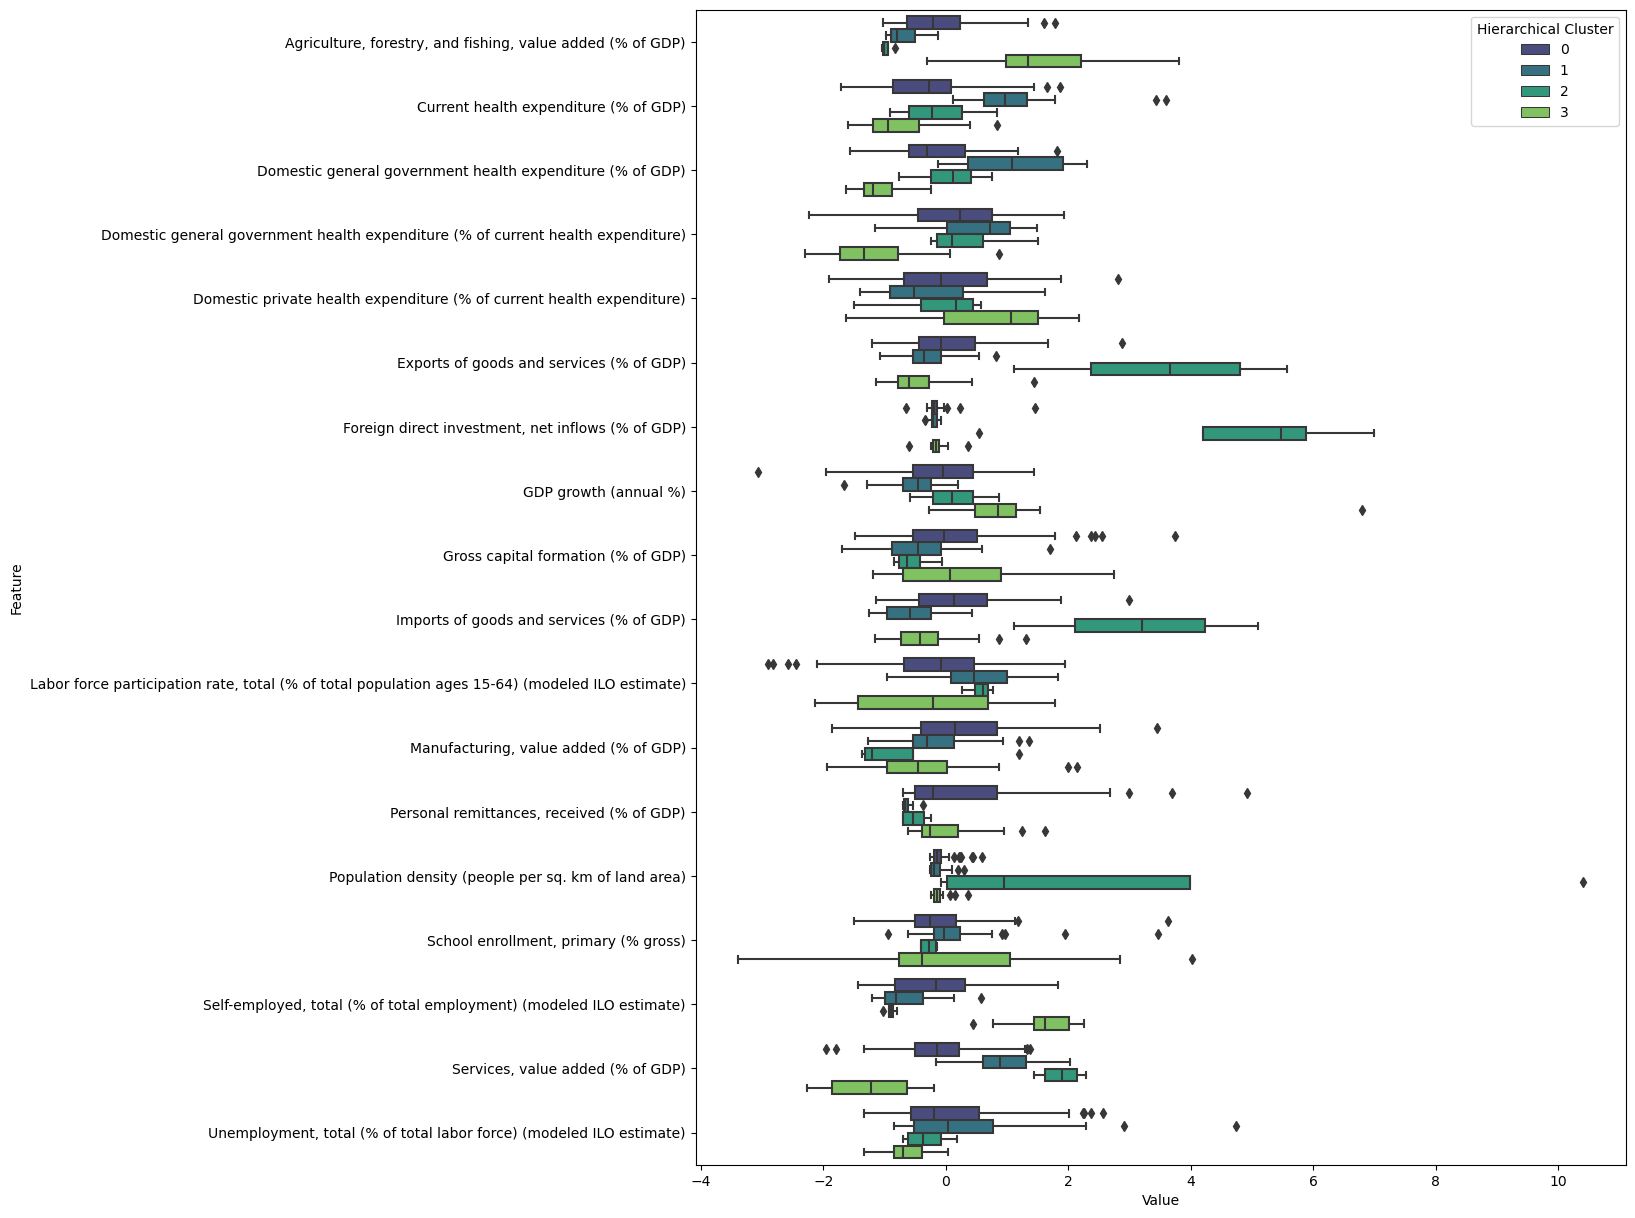

In [53]:
standard_scaler = StandardScaler()
pre_covid_final_df.iloc[:, 8:] = standard_scaler.fit_transform(pre_covid_final_df.iloc[:, 8:])

pre_melted_df = pre_covid_final_df.melt(id_vars=['Hierarchical Cluster'], 
                                    value_vars=pre_covid_final_df.columns[8:], 
                                    var_name='Feature', value_name='Value')

plt.figure(figsize=(12, 15))
sns.boxplot(y="Feature", x="Value", hue="Hierarchical Cluster", palette="viridis", data=pre_melted_df)
plt.show()

Building on the analyses established above, this analysis further uses the distribution of of the countries for all the features used to characterize and label each cluster. 

In terms of the pre-covid (2019) data, Cluster 0 is characterized by having a high manufacturing share of GDP, high remittances, and low share of service sector as share of its GDP. Additionally, their health expenditure is relatively balanced, with both government and private sector contributions. More generally, Cluster 0 can be loosely labelled as 'emerging and developing countries'.

Cluster 1, on the other hand, have the highest current and government health expenditures compared to other countries. Recall that these clustering include advanced economies such as United Kingdom, USA, and Germany that generally have higher health expenditures than other countries. More generally, Cluster 1 can be loosely labelled as 'advanced and developed countries'.


Cluster 2 noticeably has a significant trade openness characterized by its large export, imports, and FDI shares. This implies that countries in this cluster such as Singapore and Malta are trading hubs with regional and global roles in the global value chains. More generally, Cluster 1 can be loosely labelled as 'trading hub countries'.

Cluster 3 is characterize by the lowest current and government health expenditure. This cluster is also defined by its large agricultrure sector along with low contributions from its services sector. These characteristics are typical of low-income or less-developed countries. More generally, Cluster 3 can be loosely labelled as 'low income and less developed countries'.

#### Early onset COVID

In [55]:
covid_final_df = merge_dataframes(world, covid_clusters, covid)

In [56]:
covid_final_df_g1 = covid_final_df[covid_final_df['Hierarchical Cluster'] == 0]

In [57]:
covid_final_df_g2 = covid_final_df[covid_final_df['Hierarchical Cluster'] == 1]

In [58]:
covid_final_df_g3 = covid_final_df[covid_final_df['Hierarchical Cluster'] == 2]

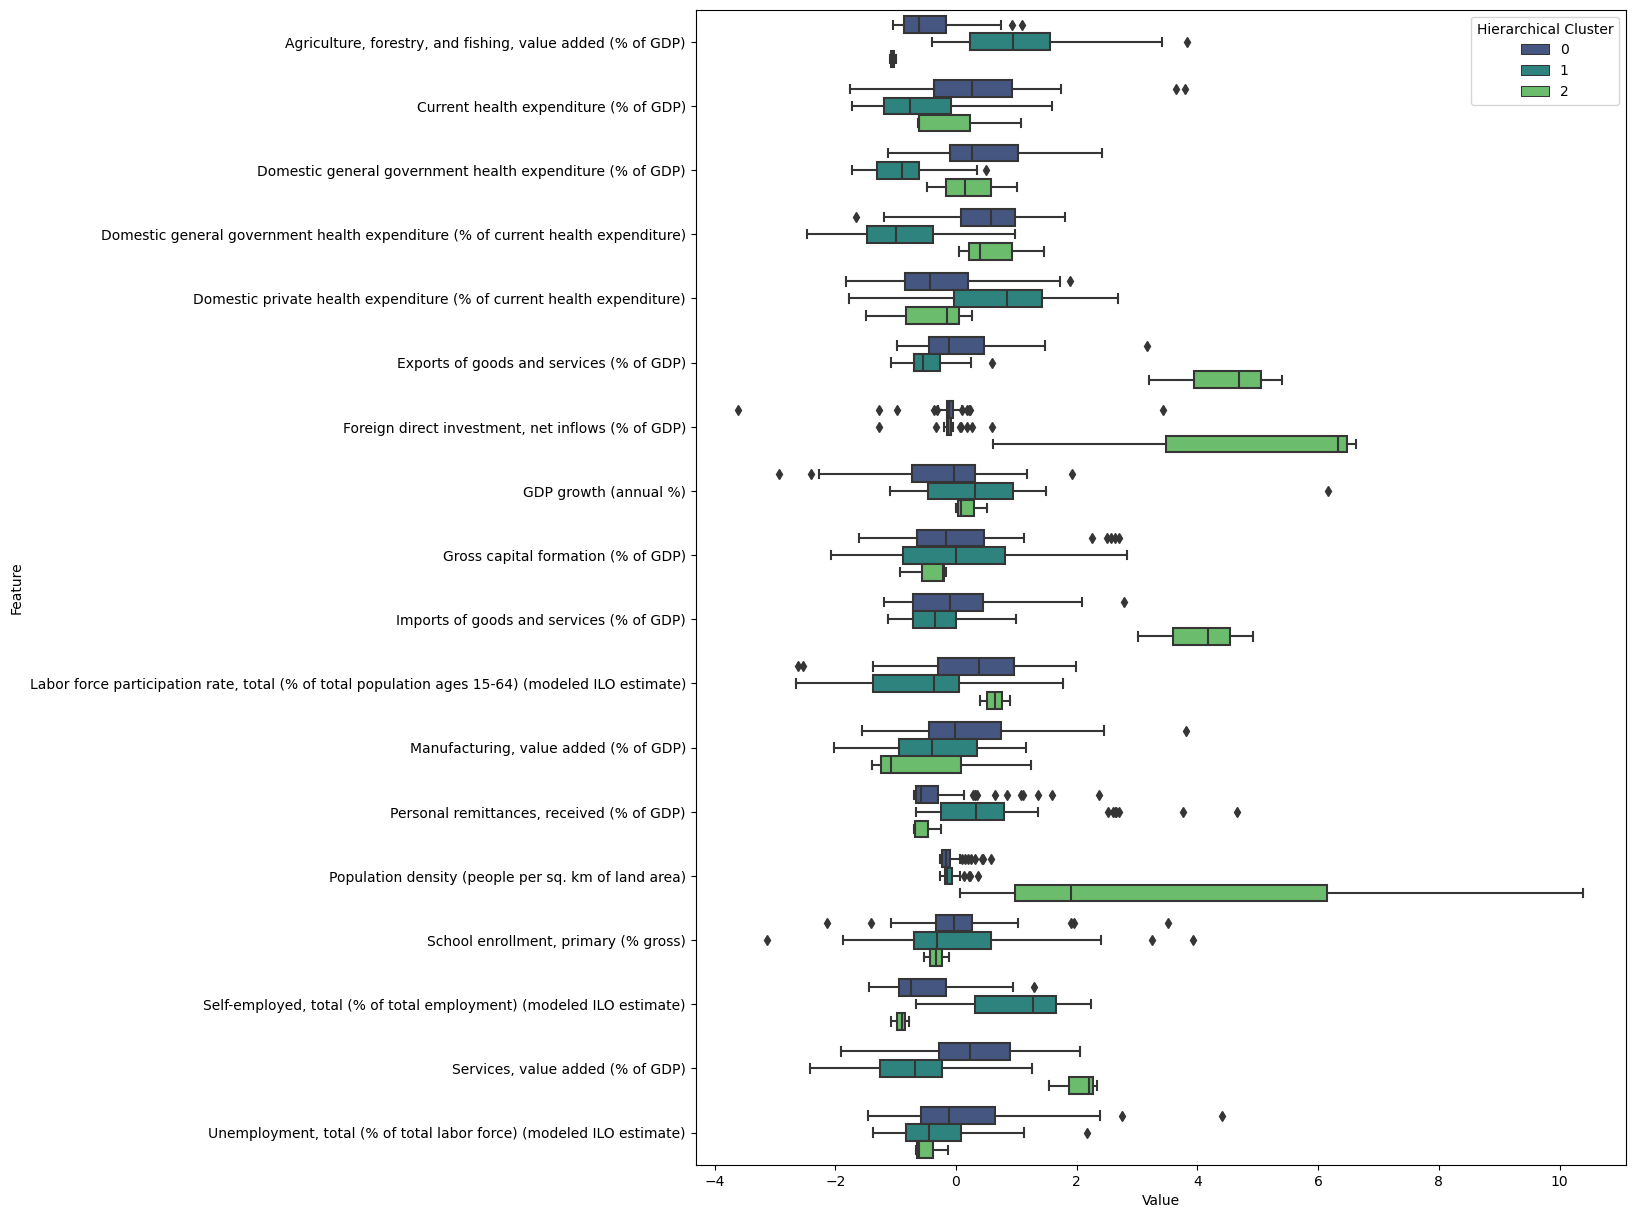

In [59]:
standard_scaler = StandardScaler()
covid_final_df.iloc[:, 8:] = standard_scaler.fit_transform(covid_final_df.iloc[:, 8:])

covid_melted_df = covid_final_df.melt(id_vars=['Hierarchical Cluster'], 
                                    value_vars=covid_final_df.columns[8:], 
                                    var_name='Feature', value_name='Value')

plt.figure(figsize=(12, 15))
sns.boxplot(y="Feature", x="Value", hue="Hierarchical Cluster", palette='viridis', data=covid_melted_df)
plt.show()

On the other hand, only three clusters were identified at the onset of the pandemic with each cluster distinguishable through specific features.

Cluster 0 has the highest current and government health expenditures among all the clusters. Additionally this cluster exhibited the lowest annual GDP growth for 2020 which implies that countries in these cluster were among the most economically impacted by the covid relative to their growth in 2019.

Cluster 1 has the lowest current and government health expenditures, with their health expenditures considerably lagging behind the other clusters even amidst the pandemic crisis. This cluster also had the lowest labor force participation rate during the pandemic, implying that a lot of the jobs in the countries in this clusters were directly impacted by the crisis. 


Cluster 2, similar to Cluster 3 in 2019, has the highest openness to trade with the highest export, import, and FDI shares.

#### Mid-COVID

In [61]:
mid_covid_final_df = merge_dataframes(world, mid_covid_clusters, mid_covid)

In [62]:
mid_covid_final_df_g1 = mid_covid_final_df[mid_covid_final_df['Hierarchical Cluster'] == 0]

In [63]:
mid_covid_final_df_g2 = mid_covid_final_df[mid_covid_final_df['Hierarchical Cluster'] == 1]

In [64]:
mid_covid_final_df_g3 = mid_covid_final_df[mid_covid_final_df['Hierarchical Cluster'] == 2]

In [65]:
mid_covid_final_df_g4 = mid_covid_final_df[mid_covid_final_df['Hierarchical Cluster'] == 3]

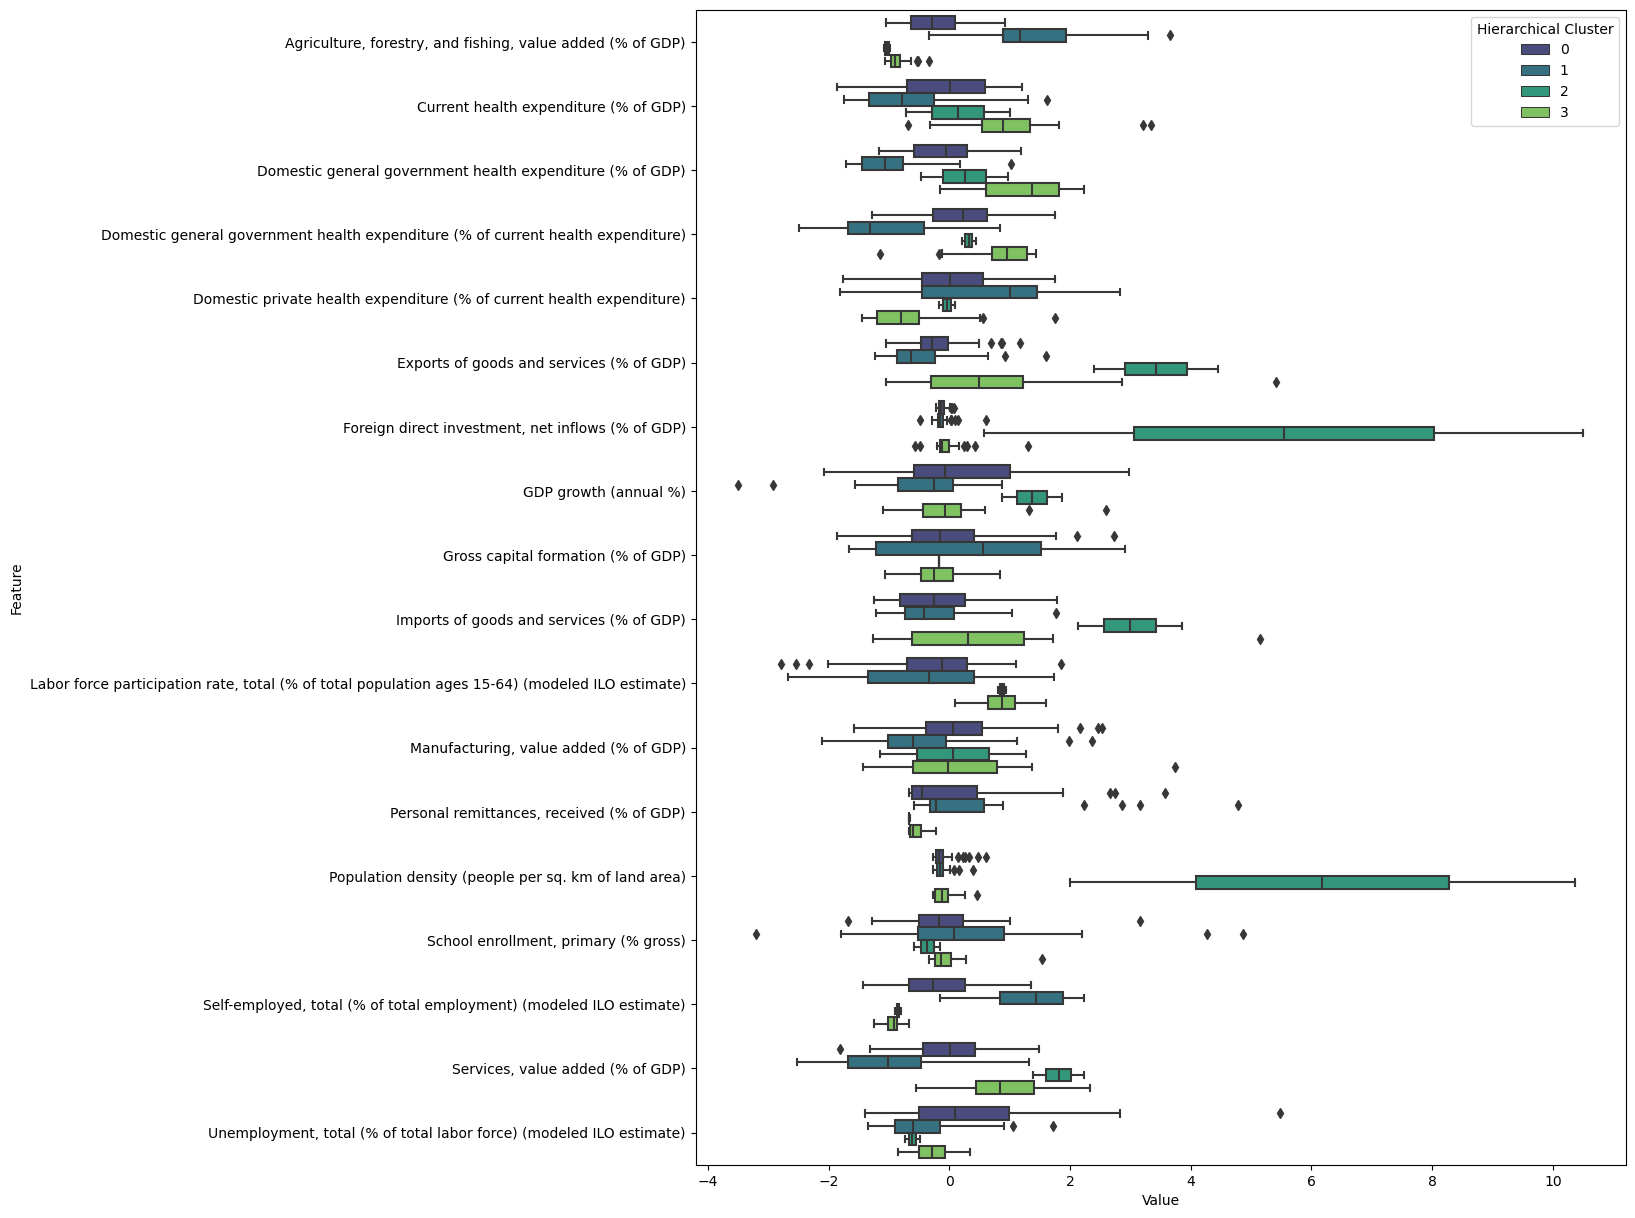

In [66]:
standard_scaler = StandardScaler()
mid_covid_final_df.iloc[:, 8:] = standard_scaler.fit_transform(mid_covid_final_df.iloc[:, 8:])

mid_melted_df = mid_covid_final_df.melt(id_vars=['Hierarchical Cluster'], 
                                    value_vars=mid_covid_final_df.columns[8:], 
                                    var_name='Feature', value_name='Value')

plt.figure(figsize=(12, 15))
sns.boxplot(y="Feature", x="Value", hue="Hierarchical Cluster", palette="viridis", data=mid_melted_df)
plt.show()

Finally, in the middle of the covid crisis in year 2021, four clusters re-emerged.

Cluster 0, similar to Cluster 0 in 2019, this cluster is still generally characterized by having a high manufacturing share of GDP, high remittances, and low share of service sector as share of its GDP. However, this cluster now has noticeably the highest unemploymet rate in 2021.


Cluster 1 is closely comparable to Cluster 3 in 2019. In fact, all 2019 Cluster 3 countries eventually realigned to 2021 Cluster 1 grouping. This cluster is characterized by the lowest current and government health expenditure. It is also defined by its large agricultrure sector along with low contributions from its services sector.Characteristics that are typical of low-income or less-developed countries.

Cluster 2, similar to Cluster 2 in 2019 and in 2020, have the highest export, import, and FDI shares, indicative of countries that are considered as trading hubs.

Cluster 3 is closely comparable to 2019 Cluster 1 that include a lot of the advanced and high income economics. This cluster is characteristic of high current and government health expenditures.

### LIME-Based Explainability

In [68]:
def lime_explanation(df, target_col="Hierarchical Cluster", exclude_cols=None):
    """
    Explains the predictions of an XGBoost clustering model using LIME.

    Arguments:
        df (pd.DataFrame): 
            The input DataFrame containing country-level features and cluster labels.

    Keyword Arguments:
        target_col (str, optional): 
            The column name representing the target variable (default: `"Hierarchical Cluster"`).
        exclude_cols (list of str, optional): 
            A list of columns to exclude from feature selection 
            (default: `["K-Means Cluster", "OPTICS Cluster", "color_code", "status"]`).
    
    Returns:
        None: 
            Displays LIME feature importance plots for one representative sample 
            from each cluster.
    """    
    if exclude_cols is None:
        exclude_cols = ["K-Means Cluster",
                        "OPTICS Cluster", "color_code", "status"]

    df = df.set_index("country_name")
    df = pd.get_dummies(df, columns=["region", "continent"], drop_first=True)

    X = df.drop(columns=[target_col] + exclude_cols)
    y = df[target_col]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = xgboost.XGBClassifier()
    model.fit(X_scaled, y)

    feature_names = X.columns

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        X_scaled,
        feature_names=feature_names,
        class_names=np.unique(y).astype(str),
        mode="classification"
    )

    unique_clusters = np.unique(y)
    samples_per_cluster = {}

    for cluster in unique_clusters:
        sample_idx = np.where(y == cluster)[0][0]
        samples_per_cluster[cluster] = sample_idx

    for cluster, sample_idx in samples_per_cluster.items():
        sample = X_scaled[sample_idx]
        exp = lime_explainer.explain_instance(
            sample, model.predict_proba, num_features=15)

        print(f"\nLIME Explanation for Cluster {cluster}:")
        # exp.show_in_notebook()
        exp.as_pyplot_figure()
        plt.show()

#### Pre-COVID


LIME Explanation for Cluster 0:


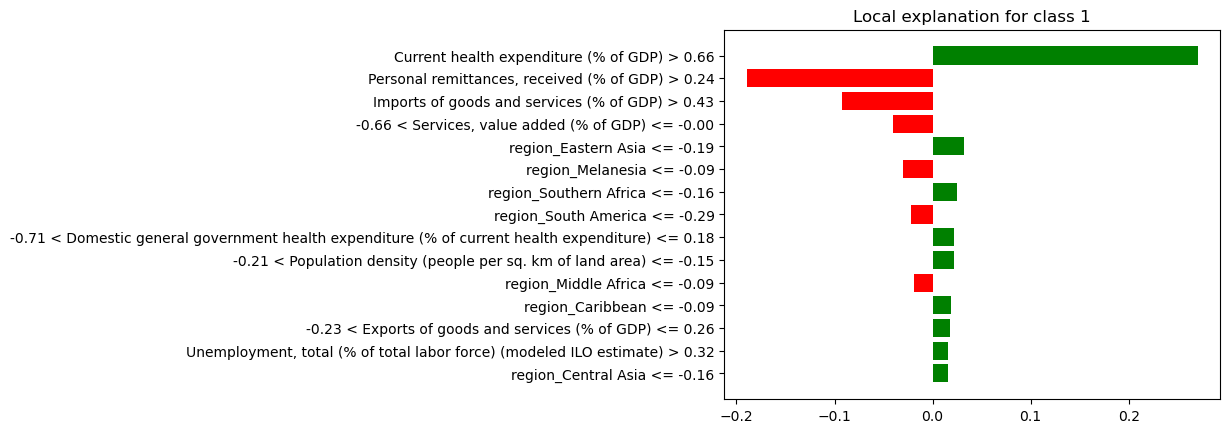


LIME Explanation for Cluster 1:


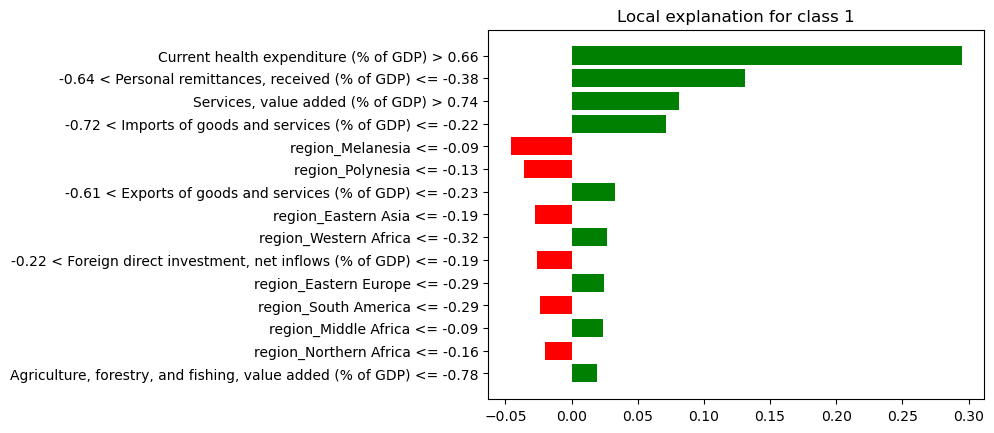


LIME Explanation for Cluster 2:


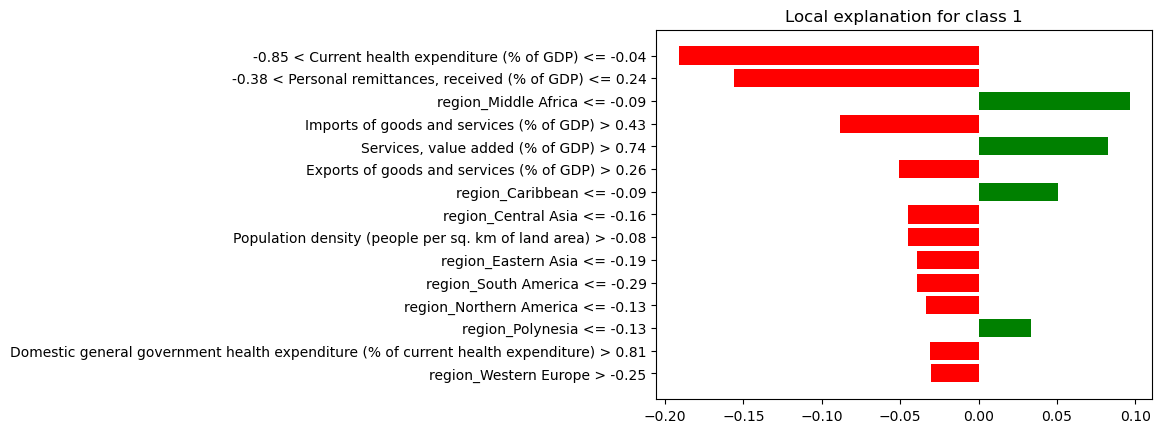


LIME Explanation for Cluster 3:


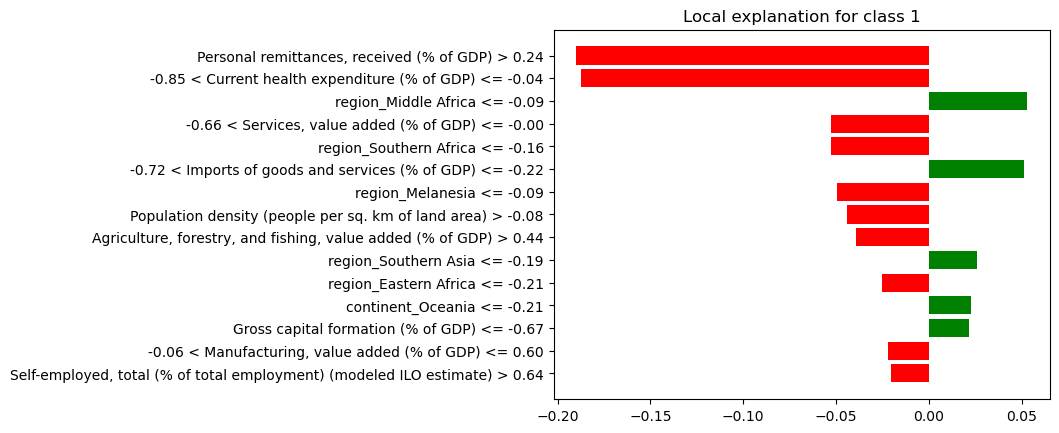

In [70]:
lime_explanation(pre_covid_final_df)

#### Early onset COVID


LIME Explanation for Cluster 0:


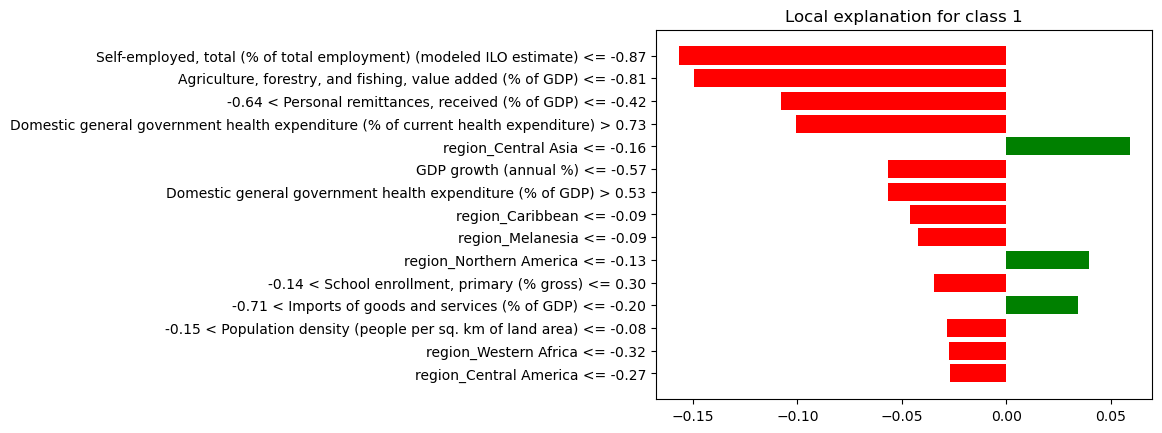


LIME Explanation for Cluster 1:


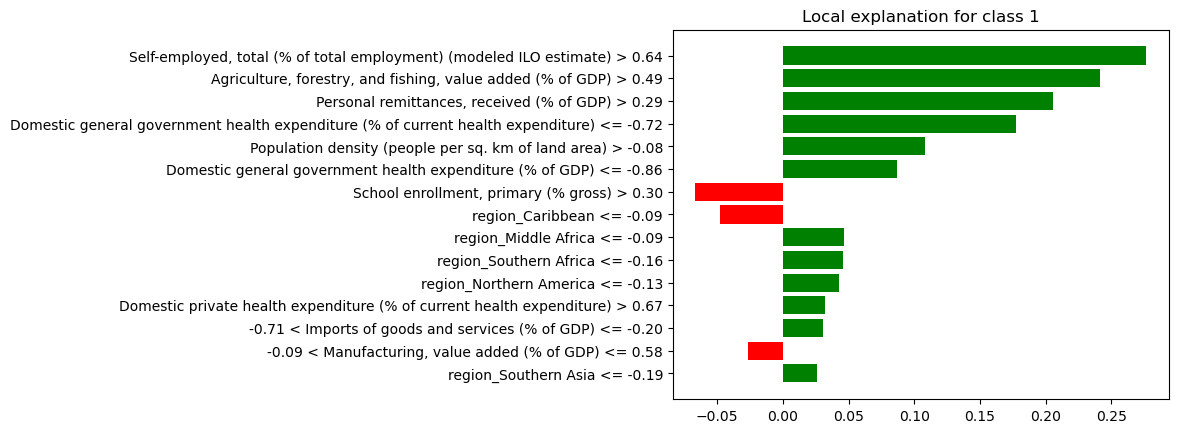


LIME Explanation for Cluster 2:


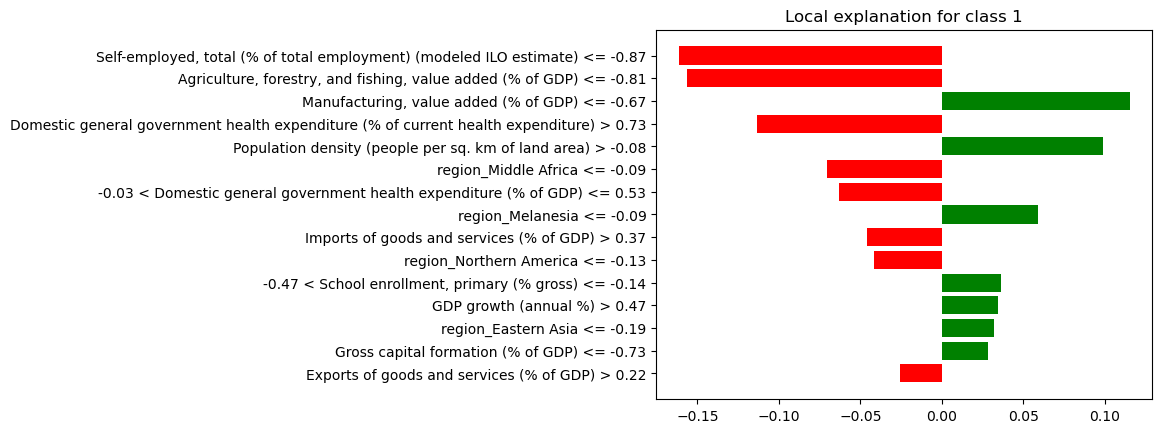

In [72]:
lime_explanation(covid_final_df)

#### Mid-COVID


LIME Explanation for Cluster 0:


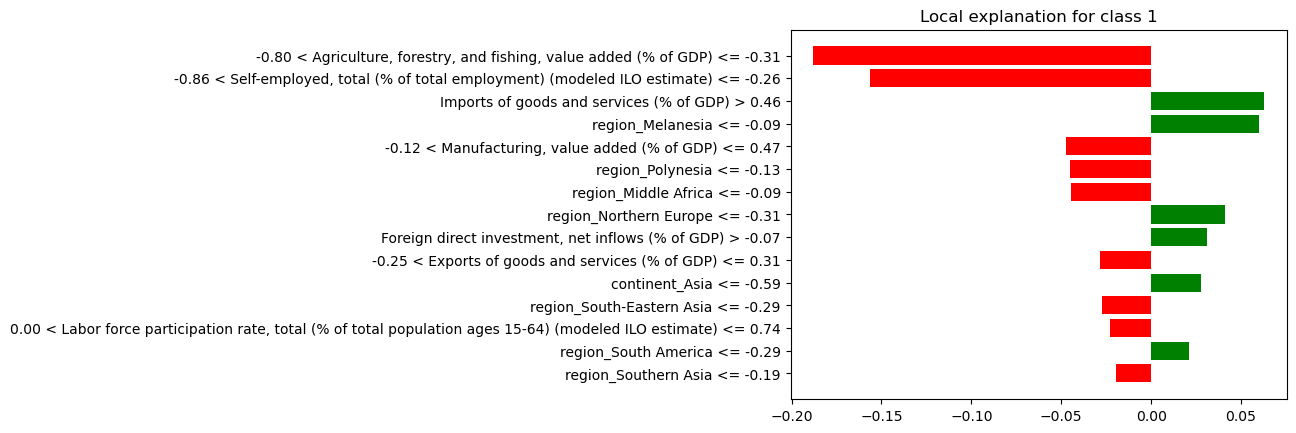


LIME Explanation for Cluster 1:


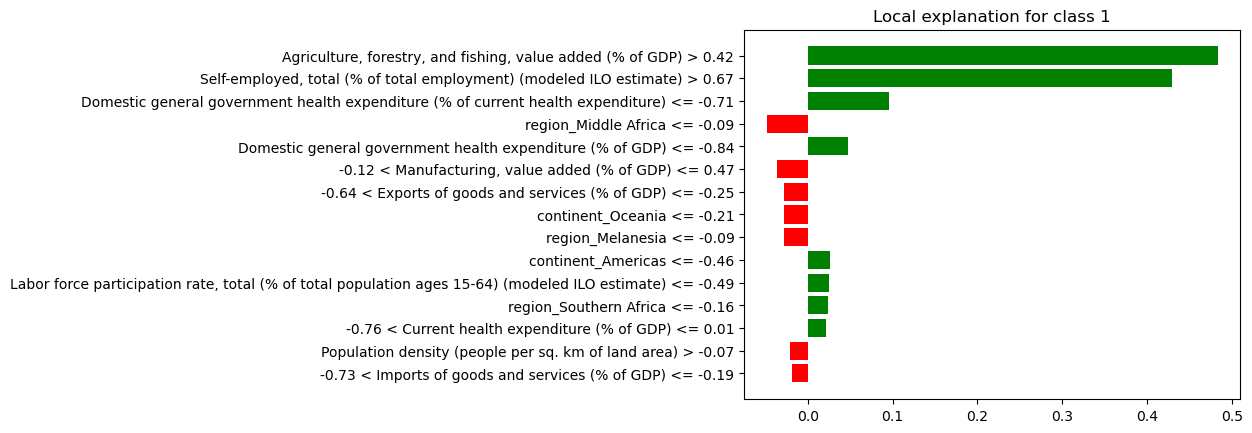


LIME Explanation for Cluster 2:


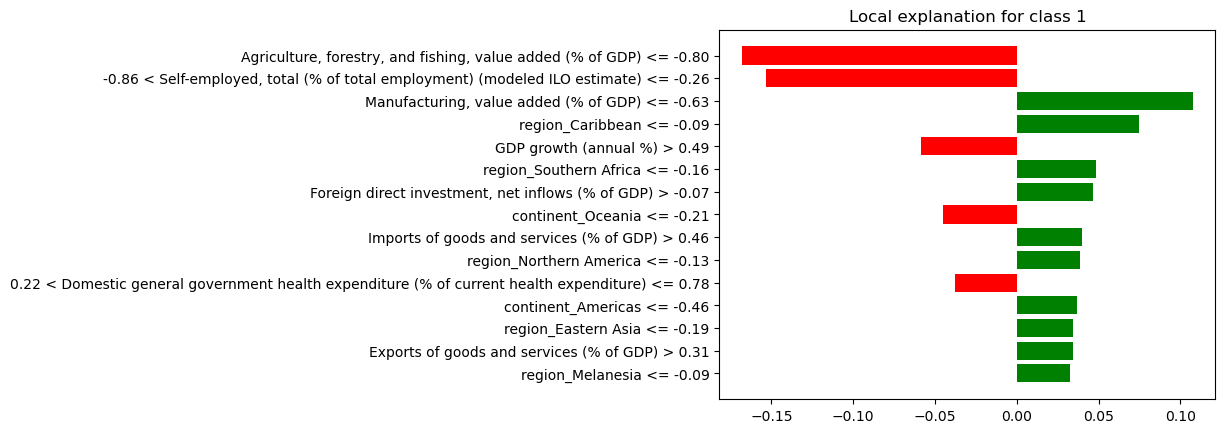


LIME Explanation for Cluster 3:


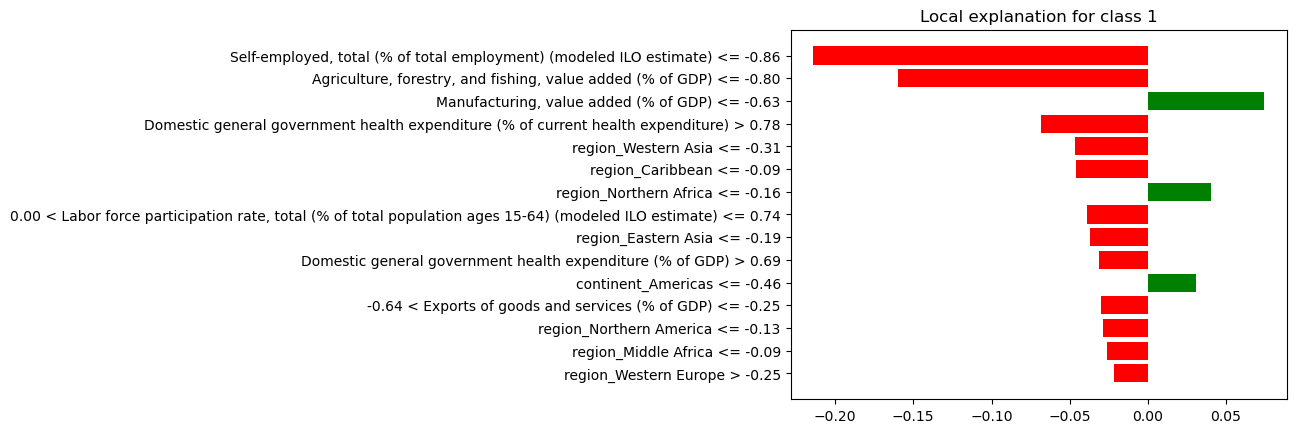

In [74]:
lime_explanation(mid_covid_final_df)

To gain deeper insights into the structural composition of economic clusters across the Pre-COVID (2019), Early COVID (2020), and Mid-COVID (2021) periods, a Local Interpretable Model-Agnostic Explanation (LIME) analysis was conducted. This approach allows for the identification of the most influential economic indicators that contributed to the classification of economies within each cluster. By examining how key features changed in importance over time, the analysis provides valuable insights into structural persistence, economic adaptation, and long-term shifts in economic grouping.

Pre-COVID (2019): Baseline Economic Structure
During the pre-pandemic period, the LIME results indicate that economic clustering was primarily influenced by health expenditure, remittance inflows, trade openness (imports and exports), and sectoral composition. Cluster 0 was strongly associated with high healthcare expenditure, suggesting that economies in this group had greater public or private investment in healthcare. Conversely, economies with higher reliance on remittances and imports were less likely to be in Cluster 0, indicating that self-sufficiency and strong domestic spending played a role in distinguishing this cluster. Cluster 1 economies were characterized by a strong services sector and high current health expenditure, whereas Cluster 2 and Cluster 3 economies exhibited lower healthcare spending and limited openness to trade. 

Early COVID (2020): Structural Adjustments and Economic Reorganization
By the onset of the pandemic, LIME explanations reveal a shift in the defining features of economic clustering. The most influential indicators now included self-employment rates, agriculture’s share of GDP, and government health expenditure. Cluster 0 economies became more associated with low self-employment and public healthcare investment, reflecting the economic shifts prompted by pandemic response measures and labor market disruptions. Meanwhile, Cluster 1 economies were characterized by higher share of agriculture sector share to GDP and personal remittance inflows, suggesting that financial support from expatriates may have helped sustain household consumption in these low-income economies.  Notably, trade-based indicators (exports and imports) became less dominant in determining cluster assignments, suggesting that global trade disruptions affected economies in a more complex manner than simple trade dependency ratios.

Mid-COVID (2021): Diverging Recovery Paths and Structural Realignment
By 2021, LIME results show a further evolution in the structural composition of economic clusters, with manufacturing output, self-employment, foreign direct investment (FDI), deomestic general government health expenditure as critical factors. Cluster 0 economies were now strongly associated with manufacturing value added and increased trade openness, suggesting a shift toward industrial recovery. In contrast, Cluster 1 exhibited a balance between self-employment and agricultural reliance, indicating that some economies retained their pre-pandemic structure despite the shocks. Clusters 2 and 3 remained characterized by weaker trade activity, lower government health spending indicating that economies in these groups struggled to return to pre-pandemic structural alignment. The increasing importance of FDI and export growth suggests that economies more integrated into global supply chains experienced faster recovery.

### Jaccard Similarity Analysis

In [76]:
def jaccard_index_per_group(pre_covid_df, early_covid_df, mid_covid_df, cluster_col="Hierarchical Cluster"):
    """
    Computes the Jaccard index to measure the stability of clusters across three time periods: 
    Pre-COVID, Early onset COVID, and Mid-COVID.

    Arguments:
        pre_covid_df (pd.DataFrame): 
            A DataFrame containing cluster assignments for the Pre-COVID period, indexed by country.
        early_covid_df (pd.DataFrame): 
            A DataFrame containing cluster assignments for the Early onset COVID period, indexed by country.
        mid_covid_df (pd.DataFrame): 
            A DataFrame containing cluster assignments for the Mid-COVID period, indexed by country.

    Keyword Arguments:
        cluster_col (str, optional): 
            The column name representing the cluster labels in each DataFrame (default: `"Hierarchical Cluster"`).

    Returns:
        pd.DataFrame: 
            A square Jaccard similarity matrix where each row and column represent clusters 
            from different time periods. The values indicate the Jaccard index between clusters.
    """    
    merged_df = pre_covid_df[[cluster_col]].merge(early_covid_df[[
                                                  cluster_col]], left_index=True, right_index=True, suffixes=("_pre", "_early"))
    merged_df = merged_df.merge(mid_covid_df[[cluster_col]], left_index=True, right_index=True, suffixes=(
        "", "_mid")).rename(columns={cluster_col: f"{cluster_col}_mid"})

    pre_clusters = sorted(merged_df[f"{cluster_col}_pre"].unique())
    early_clusters = sorted(merged_df[f"{cluster_col}_early"].unique())
    mid_clusters = sorted(merged_df[f"{cluster_col}_mid"].unique())

    unified_labels = ([f"Pre-COVID Group {c}" for c in pre_clusters] +
                      [f"Early onset COVID Group {c}" for c in early_clusters] +
                      [f"Mid-COVID Group {c}" for c in mid_clusters])

    num_clusters = len(unified_labels)
    jaccard_matrix = np.zeros((num_clusters, num_clusters))

    cluster_to_index = {
        {f"Pre-COVID Group {c}": (merged_df[merged_df[f"{cluster_col}_pre"] == c].index) for c in pre_clusters},
        {f"Early onset COVID Group {c}": (merged_df[merged_df[f"{cluster_col}_early"] == c].index) for c in early_clusters},
        {f"Mid-COVID Group {c}": (merged_df[merged_df[f"{cluster_col}_mid"] == c].index) for c in mid_clusters},
    }

    for i, cluster_i in enumerate(unified_labels):
        for j, cluster_j in enumerate(unified_labels):
            set_i = set(cluster_to_index[cluster_i])
            set_j = set(cluster_to_index[cluster_j])
            jaccard_matrix[i, j] = len(
                set_i & set_j) / len(set_i | set_j) if len(set_i | set_j) > 0 else 0

    jaccard_df = pd.DataFrame(
        jaccard_matrix, index=unified_labels, columns=unified_labels)

    return jaccard_df

In [77]:
jaccard_per_group = jaccard_index_per_group(
    pre_covid_clusters, covid_clusters, mid_covid_clusters)

In [78]:
def jaccard_index_all(pre_covid_df, early_covid_df, mid_covid_df, cluster_col="Hierarchical Cluster"):
    """
    Computes the overall Jaccard similarity scores between cluster assignments 
    across three time periods: Pre-COVID, Early onset COVID, and Mid-COVID.

    Arguments:
        pre_covid_df (pd.DataFrame): 
            A DataFrame containing cluster assignments for the Pre-COVID period, indexed by country.
        early_covid_df (pd.DataFrame): 
            A DataFrame containing cluster assignments for the Early onset COVID period, indexed by country.
        mid_covid_df (pd.DataFrame): 
            A DataFrame containing cluster assignments for the Mid-COVID period, indexed by country.

    Keyword Arguments:
        cluster_col (str, optional): 
            The column name representing the cluster labels in each DataFrame (default: `"Hierarchical Cluster"`).

    Returns:
        pd.DataFrame: 
            A symmetric DataFrame where rows and columns represent the three time periods 
            (`"Pre-COVID"`, `"Early onset COVID"`, `"Mid-COVID"`), and values represent the Jaccard 
            similarity score between clustering results for each period pair.
    """    
    merged_df = pre_covid_df[[cluster_col]].merge(early_covid_df[[
                                                  cluster_col]], left_index=True, right_index=True, suffixes=("_pre", "_early"))
    merged_df = merged_df.merge(mid_covid_df[[cluster_col]], left_index=True, right_index=True, suffixes=(
        "", "_mid")).rename(columns={cluster_col: f"{cluster_col}_mid"})

    y_pre = merged_df[f"{cluster_col}_pre"].to_numpy()
    y_early = merged_df[f"{cluster_col}_early"].to_numpy()
    y_mid = merged_df[f"{cluster_col}_mid"].to_numpy()

    jaccard_scores = {
        ("Pre-COVID", "Early onset COVID"): jaccard_score(y_pre, y_early, average="macro"),
        ("Early onset COVID", "Mid-COVID"): jaccard_score(y_early, y_mid, average="macro"),
        ("Pre-COVID", "Mid-COVID"): jaccard_score(y_pre, y_mid, average="macro"),
    }

    periods = ["Pre-COVID", "Early onset COVID", "Mid-COVID"]
    jaccard_matrix = pd.DataFrame(1.0, index=periods, columns=periods)

    for (p1, p2), score in jaccard_scores.items():
        jaccard_matrix.loc[p1, p2] = score
        jaccard_matrix.loc[p2, p1] = score

    return jaccard_matrix

In [79]:
jaccard_all = jaccard_index_all(
    pre_covid_clusters, covid_clusters, mid_covid_clusters)

In [80]:
def plot_jaccard_heatmap(jaccard_df, title="Jaccard Similarity Heatmap"):
    """
    Plots a heatmap to visualize the Jaccard similarity matrix.

    Arguments:
        jaccard_df (pd.DataFrame): 
            A square DataFrame containing Jaccard similarity scores between 
            different time periods (e.g., Pre-COVID, Early onset COVID, Mid-COVID).

    Keyword Arguments:
        title (str, optional): 
            The title of the heatmap (default: `"Jaccard Similarity Heatmap"`).
    
    Returns:
        None: 
            Displays the heatmap using Matplotlib and Seaborn.
    """    
    plt.figure(figsize=(12, 12))
    sns.heatmap(jaccard_df, annot=True, cmap="Blues",
                fmt=".3f", linewidths=0.5, square=True,
                cbar_kws={"shrink": 0.8})

    plt.title(title, fontsize=18, fontweight='bold')
    plt.xticks(rotation=90, fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    plt.show()

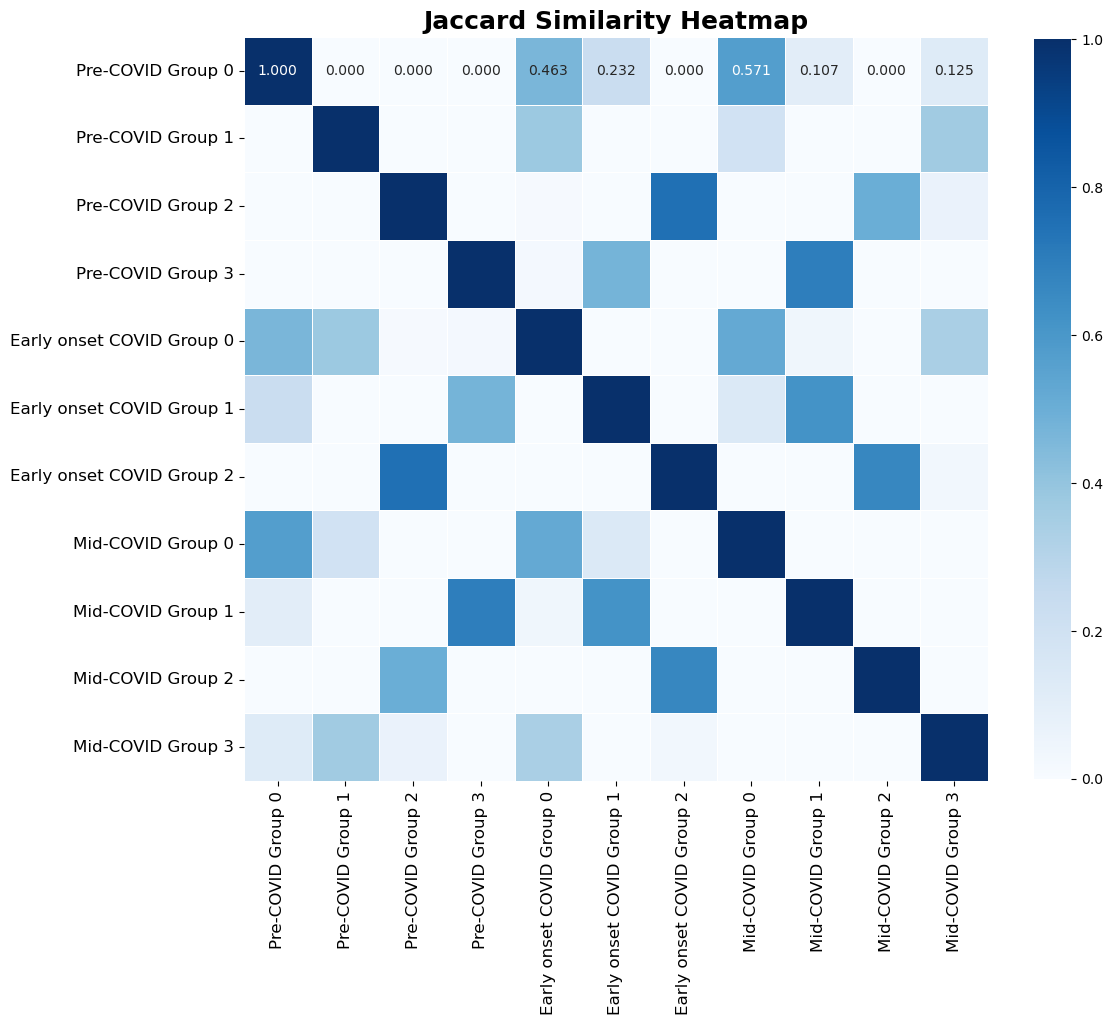

In [81]:
plot_jaccard_heatmap(jaccard_per_group)

The Jaccard similarity heatmap provides an augmenting perspective on the persistence, transition, and realignment of economic structures across the Pre-COVID (2019), Early COVID (2020), and Mid-COVID (2021) periods discussed in the analyses above. By quantifying the degree of overlap between clusters over time, the results offer valuable insights into how economies either retained their structural positioning, underwent temporary shifts before realigning, or experienced lasting structural divergence. The findings reveal that while some clusters demonstrated strong continuity, maintaining high similarity scores across the three periods, others fragmented and restructured, leading to significant economic reclassifications. These shifts suggest that the pandemic did not merely cause temporary disruptions but served as an economic stress test that revealed deeper structural differentiations among nations.

A key observation from the results is that certain clusters exhibited remarkable persistence, indicating strong macroeconomic fundamentals and institutional stability. For instance, Pre-COVID Cluster 2 displayed a high Jaccard similarity (0.750) with Early COVID Cluster 2, and Early COVID Cluster 2 retained a strong similarity (0.667) with Mid-COVID Cluster 2. This continuity suggests that economies in these groups were less affected by external shocks, likely due to diversified industrial bases, strong governance, and stable fiscal policies that enabled them to absorb economic disruptions more effectively than others. This cluster represents to the cluster containing trading hub countries such as Singapore, Malta, and Luxembourg. Similarly, Mid-COVID Cluster 0 and Pre-COVID Cluster 0 showed a Jaccard similarity of 0.571, indicating that a significant portion of economies in this cluster remained structurally aligned despite the pandemic-induced downturns. The ability of these clusters to maintain high degrees of similarity over time suggests that these economies had built-in resilience mechanisms, including robust trade networks, steady labor markets, and balanced social investment strategies.

While some clusters remained structurally intact, others underwent fragmentation and realignment, particularly during the early stages of the pandemic. The most striking example of this is Pre-COVID Cluster 0, which split across multiple clusters in Early COVID, with a notable share aligning with Early COVID Cluster 0 (0.463 similarity) while another segment transitioned to Early COVID Cluster 1 (0.232 similarity). This divergence indicates that the economic impact of the pandemic affected countries within this group unevenly, pushing some economies toward more resilient classifications while others shifted toward structurally weaker clusters, as detailed in the section above. A similar trend is observed with Pre-COVID Cluster 3, which had a 0.475 similarity with Early COVID Cluster 1, suggesting that several economies that were initially in a structurally weaker position prior to the pandemic were further pushed toward economic vulnerability during the early phases of the crisis. These shifts highlight how the pandemic acted as a structural differentiator, exposing underlying disparities in economic adaptability, fiscal capacity, and policy agility.

By Mid-COVID (2021), the Jaccard similarity scores indicate a degree of economic reversion, where certain economies that initially diverged during the pandemic realigned with their pre-pandemic clusters. For example, Mid-COVID Cluster 0 shares a Jaccard similarity of 0.523 with Early COVID Cluster 0 and 0.571 with Pre-COVID Cluster 0, suggesting that some economies that had shifted in 2020 were able to recover and reintegrate into their original structural classification. Similarly, Mid-COVID Cluster 1 has a 0.619 similarity with Early COVID Cluster 1 and a 0.700 similarity with Pre-COVID Group 2, indicating that while this cluster had been reconfigured during the pandemic, it gradually stabilized in alignment with structurally similar economies. However, not all economies that diverged in 2020 managed to return to their original clusters, as seen in the low similarity scores between some Pre-COVID and Mid-COVID clusters. This suggests that while some economies demonstrated resilience and policy-driven recovery, others suffered long-term economic transformations that prevented them from returning to their pre-pandemic classifications.



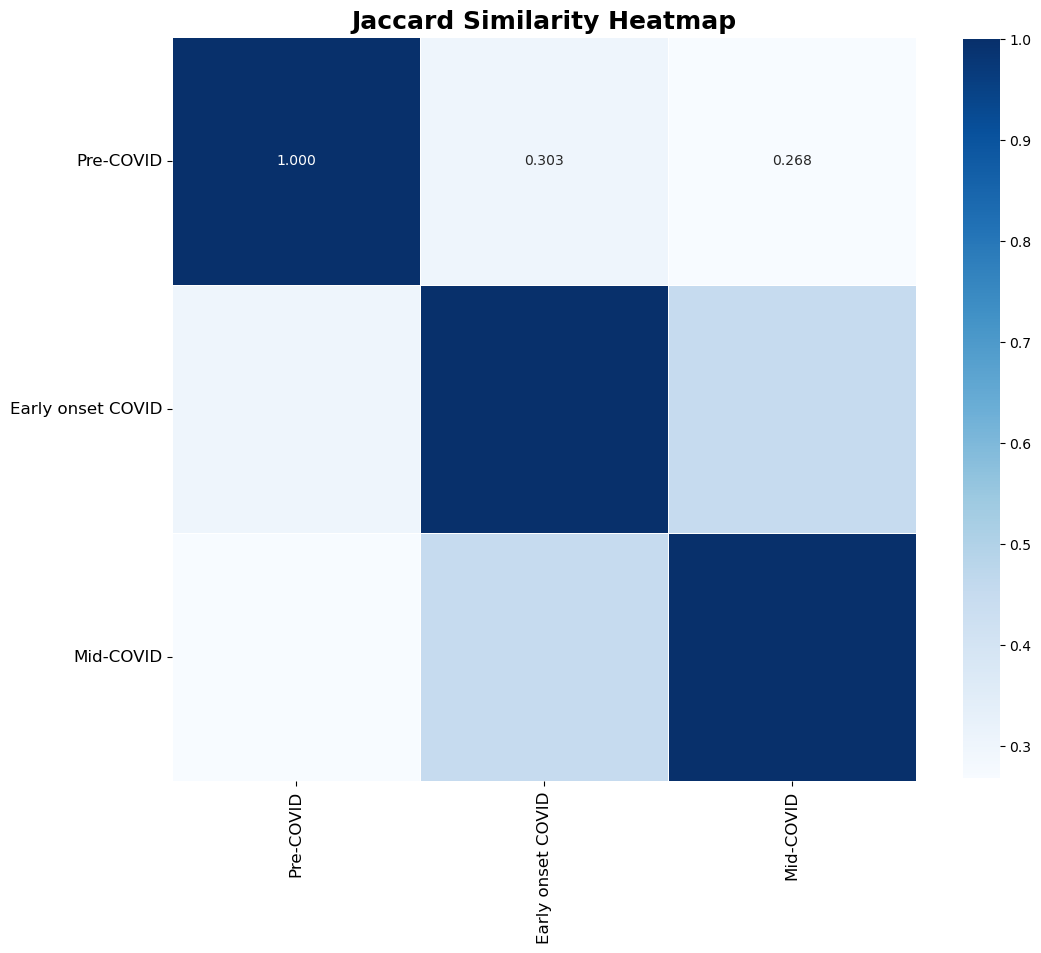

In [82]:
plot_jaccard_heatmap(jaccard_all)

The broader Jaccard similarity analysis highlights the extent of economic restructuring between the three periods. The low similarity score (0.303) between Pre-COVID and Early COVID clusters indicates that nearly 70% of economic classifications were disrupted during the initial pandemic shock. This suggests that many economies underwent significant structural shifts, likely driven by sectoral contractions, trade breakdowns, fiscal pressures, and employment instability. However, by Mid-COVID, the similarity between Early COVID and Mid-COVID clusters increased to 0.452, showing that while some economies continued evolving post-pandemic, a degree of stabilization and persistence emerged. Yet, the Pre-COVID to Mid-COVID similarity remains low at 0.268, reinforcing that many of the pandemic-induced shifts were not temporary, and several economies realigned into fundamentally new macroeconomic classifications.

These findings suggest that rather than a full return to pre-pandemic structures, the crisis reshaped the global economic landscape, effectively “sorting” economies into new classifications. Countries that recovered their original structural alignment likely had relatively stronger institutional resilience, more diversified economies, and more flexible fiscal policies, while those that remained in new clusters likely suffered from persistent vulnerabilities, including dependence on volatile sectors such as tourism or extractive industries. The rising similarity between Early COVID and Mid-COVID clusters suggests that pandemic-induced economic transformations were not short-lived, but instead represented deeper structural adjustments.

# Conclusion

This study sought to examine how the structural clustering of economies evolved over three key periods—Pre-COVID (2019), Early COVID (2020), and Mid-COVID (2021)—using hierarchical clustering and Jaccard similarity analysis to track shifts in economic composition. The results provide a clear answer to the stated problem: while some economies maintained their structural positioning over time, others experienced significant fragmentation and reorganization, particularly at the onset of the pandemic, followed by varying degrees of realignment in 2021. The findings confirm that the pandemic did not simply cause temporary disruptions but led to measurable structural shifts, revealing key differences in how economies adapted to external shocks. These shifts were not merely a function of economic development level but rather reflected differences in trade dependencies, fiscal strategies, labor market structures, and sectoral resilience.

One of the most critical takeaways from this research is that the pandemic acted as a catalyst for structural differentiation rather than uniformly affecting all economies in the same way. The fragmentation of 2019 Cluster 0 into different clusters in 2020, followed by the partial but incomplete realignment in 2021, illustrates that different economies responded to and recovered from disruptions at different speeds. Some countries successfully reintegrated into their original clusters, suggesting that their economic structures remained fundamentally intact despite the temporary shock, while others remained in newly formed clusters, indicating more permanent structural reclassification. The Jaccard similarity results further reinforce this, as the low similarity between Pre-COVID and Mid-COVID clusters suggests that while some realignment occurred, a complete return to pre-pandemic structures was not universal.

This project also highlights the recurring factors contributed to structural persistence versus realignment. Economies that maintained high similarity scores across periods tended to have high health expenditures, high receipt of personal remittances, and resilient trade relationships allowing them to navigate volatility without major structural shifts. Conversely, economies that underwent the most pronounced shifts between clusters were those with concentrated sectoral dependencies (such as reliance on tourism, remittances, or extractive industries), fiscal constraints, or weaker labor market stability. This finding is reflective of the importance of analyzing economies not as fixed entities but as dynamic structures that evolve in response to global disruptions, with some demonstrating greater adaptability and stability than others.

Ultimately, this study provides a data-driven perspective on how economies grouped and regrouped based on structural characteristics rather than conventional classifications. The results demonstrate that structural clustering is fluid and can change significantly in response to external shocks, with economies either returning to prior alignments or forming new patterns of similarity. This underscores the importance of utilizing dynamic, cluster-based methodologies to analyze economic shifts over time rather than relying on static categorizations. 

# Recommendations

While this study provides a valuable foundational analysis of economic clustering and structural realignment across Pre-COVID (2019), Early COVID (2020), and Mid-COVID (2021), several limitations highlight opportunities for future research. First, the clustering methodology, while effective in capturing economic shifts, does not explicitly account for causal relationships behind these changes. The observed transitions in economic structures likely stem from a combination of policy responses, sectoral dependencies, trade disruptions, and labor market dynamics, but this study does not isolate the weight of each factor. Future research should employ causal inference techniques, such as difference-in-differences analysis or structural equation modeling, to quantify how specific economic policies influenced an economy’s likelihood of returning to its pre-pandemic cluster or remaining in a new classification. Additionally, the study primarily relies on macro-level economic indicators, which may overlook subnational variations and the role of informal economies. Expanding the dataset to include high-frequency financial data, firm-level employment statistics, or mobility-based economic activity proxies could provide a more granular perspective on economic resilience and transformation. Another major limitation of this study is the availability of data. While the research initially started with a compact set of indicators, a lot of these indicators were dropped in the process since they do not contain enough data to run the models in this project. Furthermore, the latest data this study could gather from the dataset without losing too much information for a minimum set of countries is 2021. Future research should extend the analysis to investigate whether the restructuring persisted even beyond the pandemic crisis should data becomes available. 

Moreover, while the hierarchical clustering approach effectively identified structural transitions, it lacks probabilistic interpretability and does not capture the fluidity of economic movement over time. Future studies should explore more dynamic and adaptive clustering techniques, such as Hidden Markov Models (HMM) to track how economies transition between states, or Gaussian Mixture Models (GMM), which allow for soft clustering, capturing the degree to which an economy exhibits characteristics of multiple clusters rather than being forced into a rigid classification. Additionally, while this study primarily relied on Jaccard similarity to quantify clustering persistence, incorporating temporal network analysis or spectral clustering methods could provide a deeper understanding of long-term structural dependencies and linkages between economies. Another key limitation is the study’s reliance on macro-level indicators, which do not account for subnational economic disparities or the role of informal economies in shaping resilience during shocks.

## Appendix

### A. Other Clustering Strategies

To evaluate alternative clustering methods, this study applied K-Means and DBSCAN to the Pre-COVID dataset and assessed their performance using both quantitative metrics and visual inspection. While the evaluation metrics for K-Means suggested potential optimal cluster numbers, the scatter plot of the clustered data revealed a high degree of dispersion among data points. This dispersion indicates that K-Means may not be robust in capturing the underlying structure of the dataset, as it assumes spherical clusters and struggles with irregularly shaped distributions. In contrast, OPTICS clustering was also assessed through its reachability plot, which did not reveal a well-defined cluster structure for any reachability distance. This suggests that the dataset lacks the density-based patterns that OPTICS relies on to form clusters. Similarly, DBSCAN was ineffective, as it assigned all countries to a single large cluster. This outcome indicates that the dataset does not exhibit sufficient density-based separability, making DBSCAN unsuitable for this context. Given these findings, hierarchical clustering remains the most interpretable and robust approach for segmenting countries based on their development indicators.

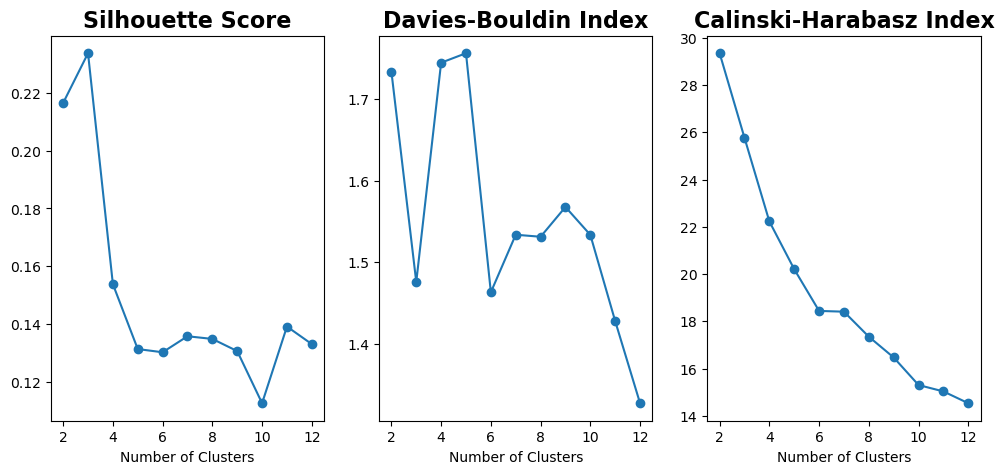

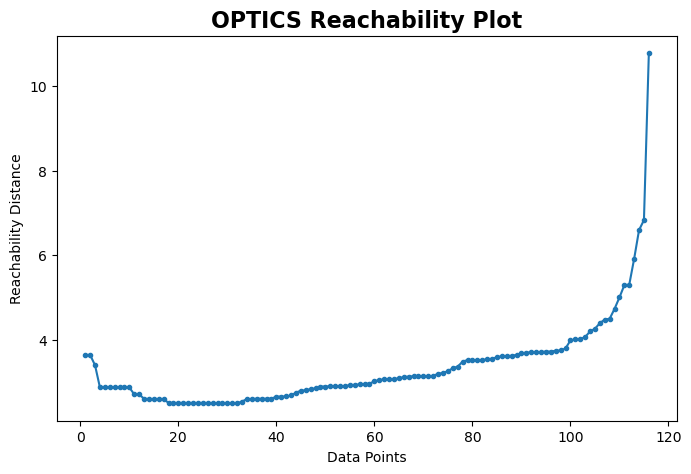

In [85]:
gridsearch_clustering(pre_covid_scaled_df, max_clusters=12, min_clusters=2, plots=["kmeans_metrics", "optics"])

Text(0.5, 1.0, 'K-Means Clusters')

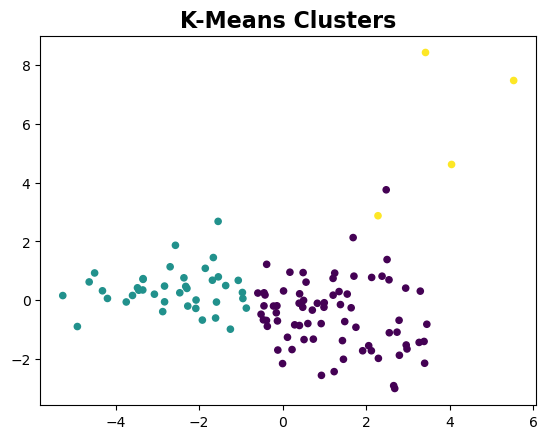

In [86]:
plt.scatter(pre_covid_pca_viz[:, 0], pre_covid_pca_viz[:, 1],
            c=pre_covid_clusters['K-Means Cluster'], cmap='viridis', s=20)
plt.title("K-Means Clusters", fontsize=16, weight='bold')

Text(0.5, 1.0, 'DBSCAN Clusters')

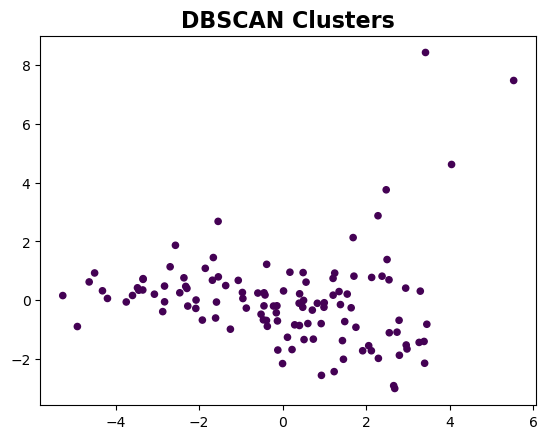

In [87]:
plt.scatter(pre_covid_pca_viz[:, 0], pre_covid_pca_viz[:, 1],
            c=pre_covid_clusters['OPTICS Cluster'], cmap='viridis', s=20)
plt.title("DBSCAN Clusters", fontsize=16, weight='bold')

## References

- The World Bank Group’s Early Support to Addressing the Coronavirus (COVID-19): Economic Response (April 2020-June 2021) - An Early-Stage Evaluation. (2023). Independent Evaluation Group. https://ieg.worldbankgroup.org/evaluations/world-bank-groups-early-support-addressing-coronavirus-covid-19-economic-response